In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import correlate
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Einleitung
In diesem Notebook soll als Ergänzung versucht werden die Regendaten sauber modellieren zu können. Dazu sollen die Daten alle auf monatliche Mittel aggregiert werden. Im Anschluss ist dann das Ziel ein Seasonal Decompose Model zu erstellen, welches die Saisonalität und den Trend der Daten abbildet. Falls dies sauberer funktionieren sollte, als mit den tagesdaten, können wir noch versuchen auch monatliche Wasserstände mit mehr Variablen vorherzusagen.

In [126]:
# ursprüngliches df der betrachteten Koeffizienten
df_important_coef = pd.read_csv('../data/prediction/df_important_coef.csv')

df_orig_level = df_important_coef['waterlevel(m)']
df_orig_level.index = pd.to_datetime(df_important_coef['date'])
df_orig_temp = df_important_coef['temperature_mean(degC)']
df_orig_temp.index = pd.to_datetime(df_important_coef['date'])
df_orig_vol = df_important_coef['discharge_vol(m3/s)']
df_orig_vol.index = pd.to_datetime(df_important_coef['date'])
df_orig_rain = df_important_coef['precipitation(mm/d)']
df_orig_rain.index = pd.to_datetime(df_important_coef['date'])

In [127]:
# Monatliche Daten zu allen Zeitreihen erstellen
df_level_monthly = df_orig_level.resample('ME').mean()
df_temp_monthly = df_orig_temp.resample('ME').mean()
df_vol_monthly = df_orig_vol.resample('ME').mean()
df_rain_monthly = df_orig_rain.resample('ME').mean()

# Saisonale Dekomposition
In diesem Abschnitt werden alle monatlich aggregierten Daten in ein saisonales Demopositionsmodell eingespeist. Ziel ist es, die Saisonalität und den Trend der Daten zu extrahieren und zu visualisieren. Die Hoffnung dabei ist, dass durch die Monatliche Aggregation die saisonalen Muster und Trends klarer hervortreten als bei den täglichen Daten. So werden beispielsweise bei den Regendaten die Täglich sehr starken Schwankungen zwischen Regentagen und trockenen Tagen geglättet, was es einfacher macht, langfristige Trends und saisonale Muster zu erkennen.

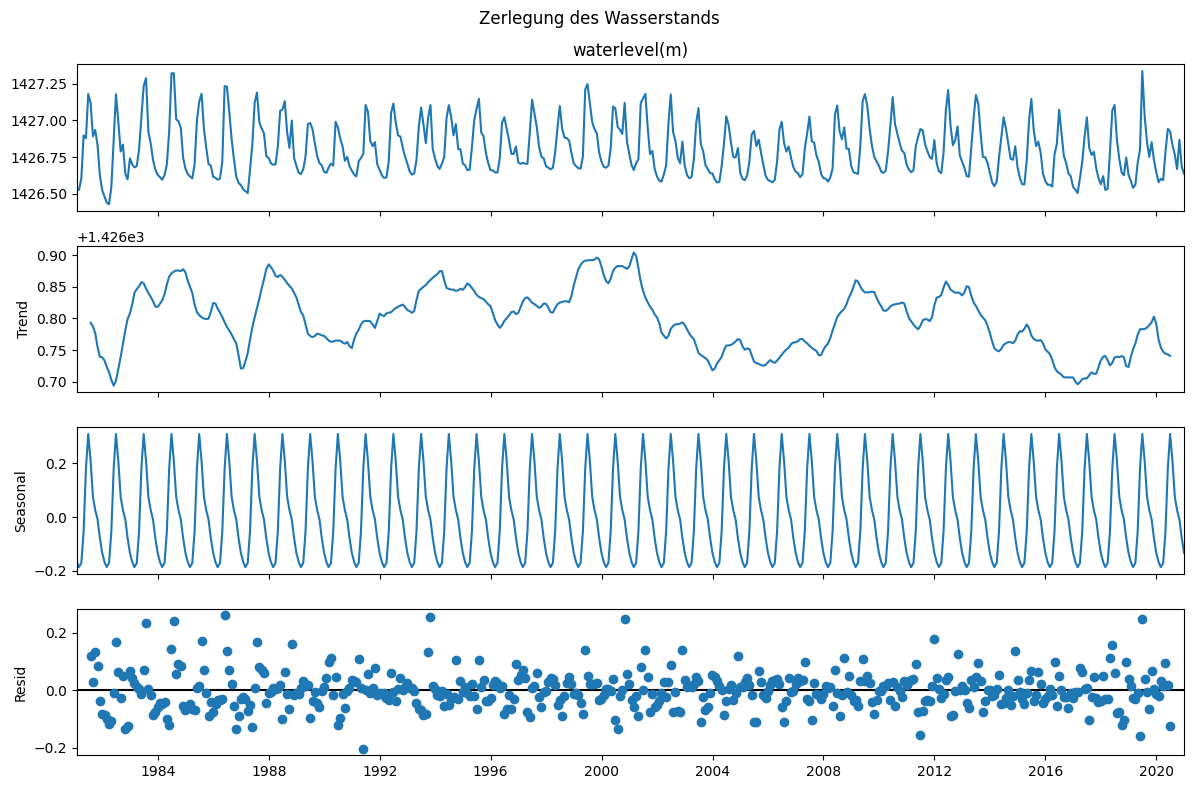

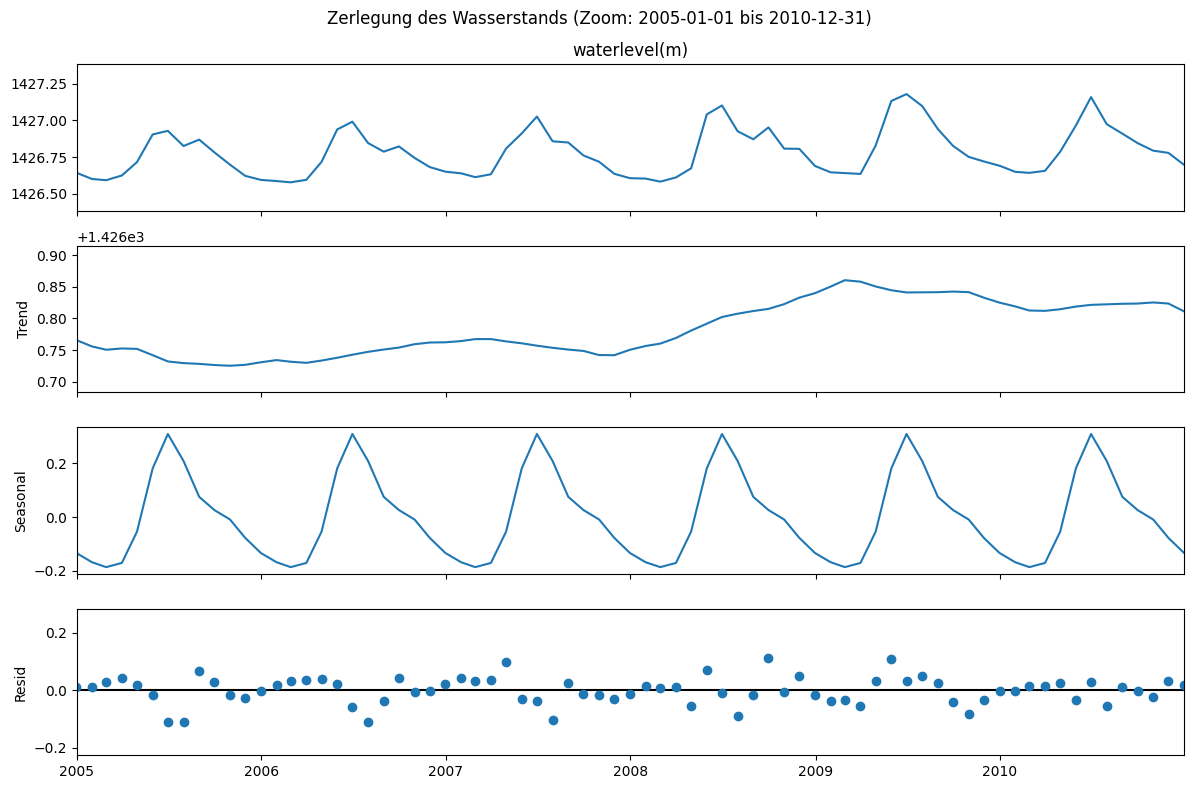

ADF p-Wert der Residuen für 'Zerlegung des Wasserstands': 0.000000
✓ Residuen sind stationaer


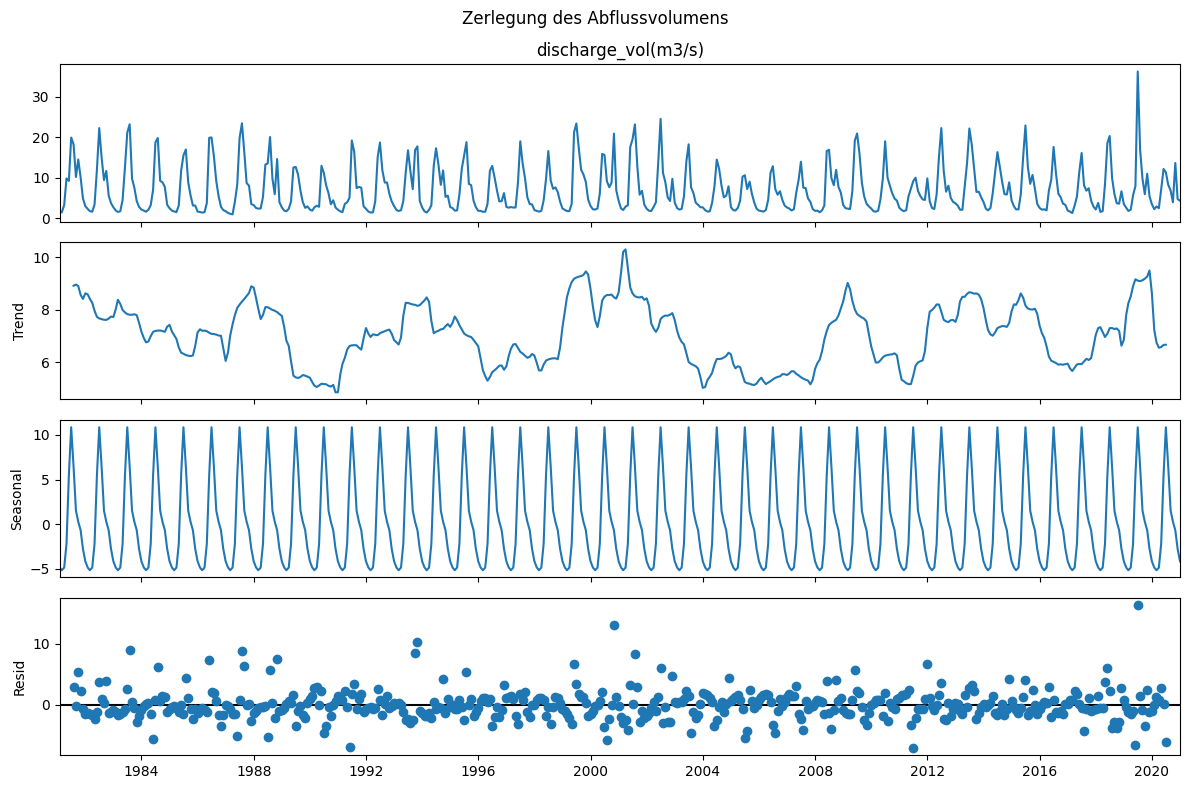

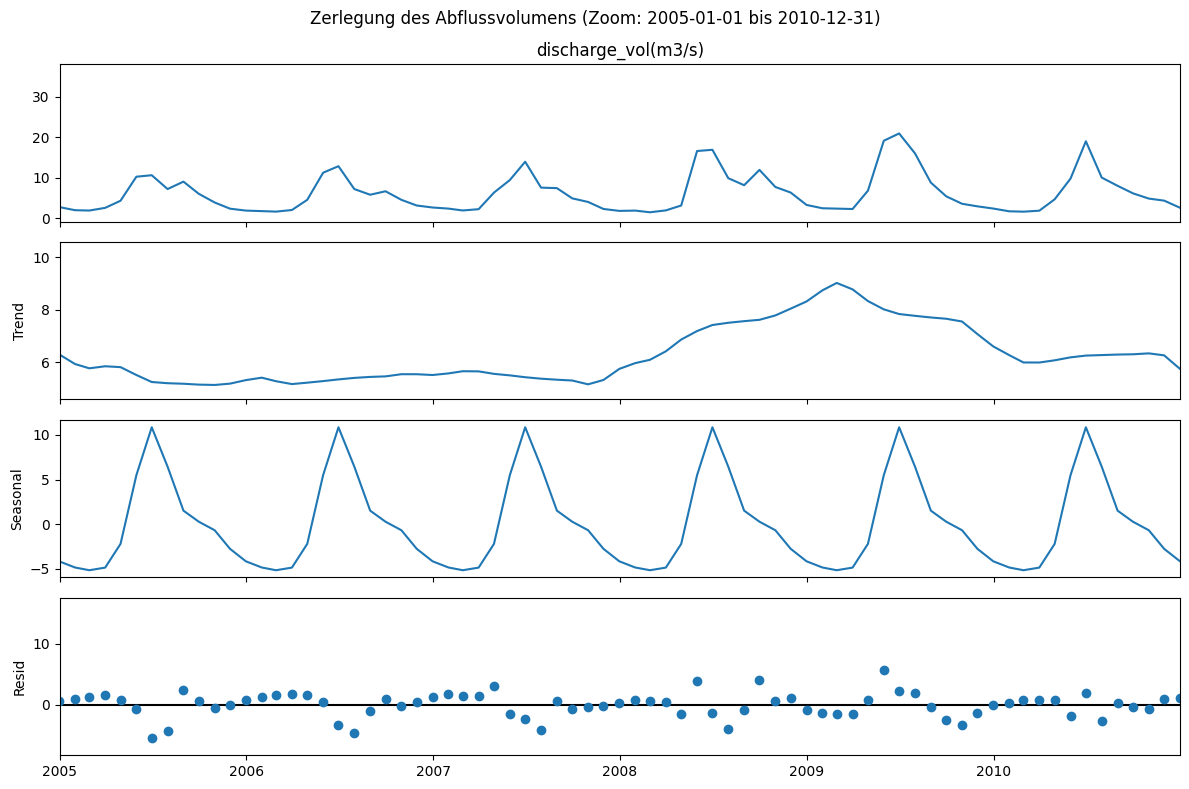

ADF p-Wert der Residuen für 'Zerlegung des Abflussvolumens': 0.000000
✓ Residuen sind stationaer


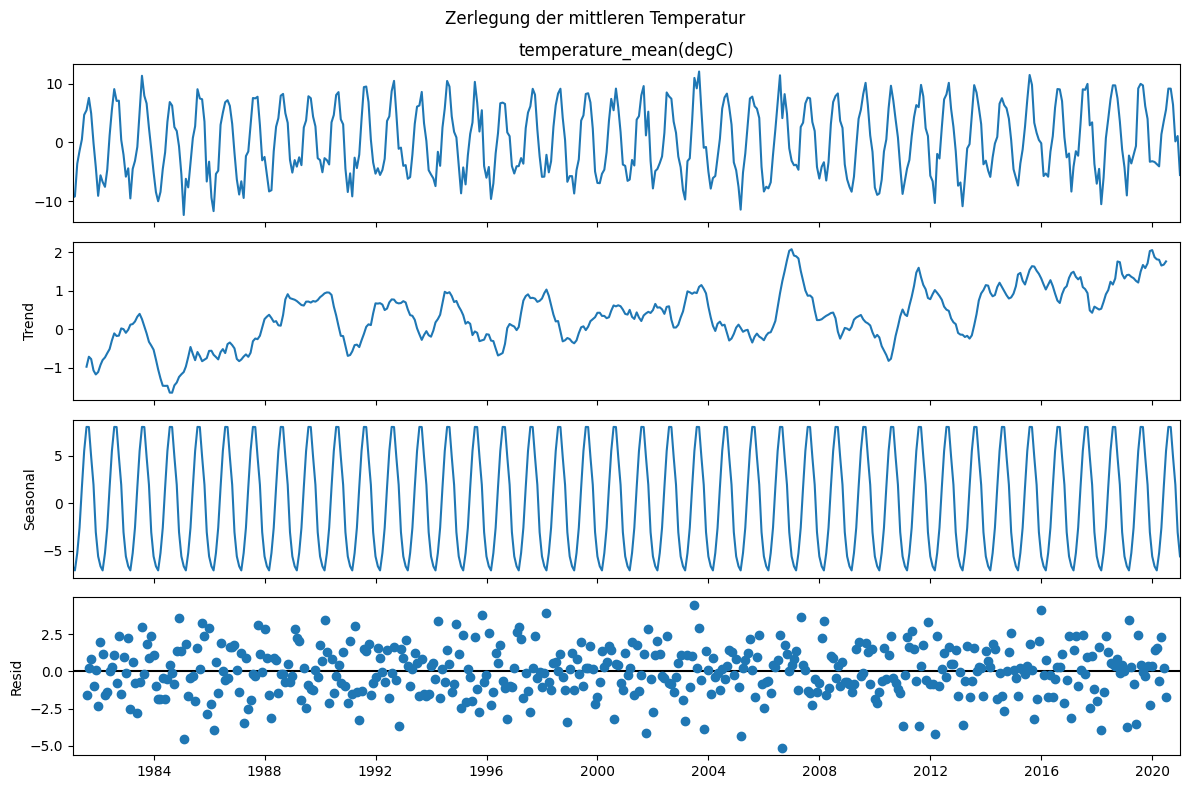

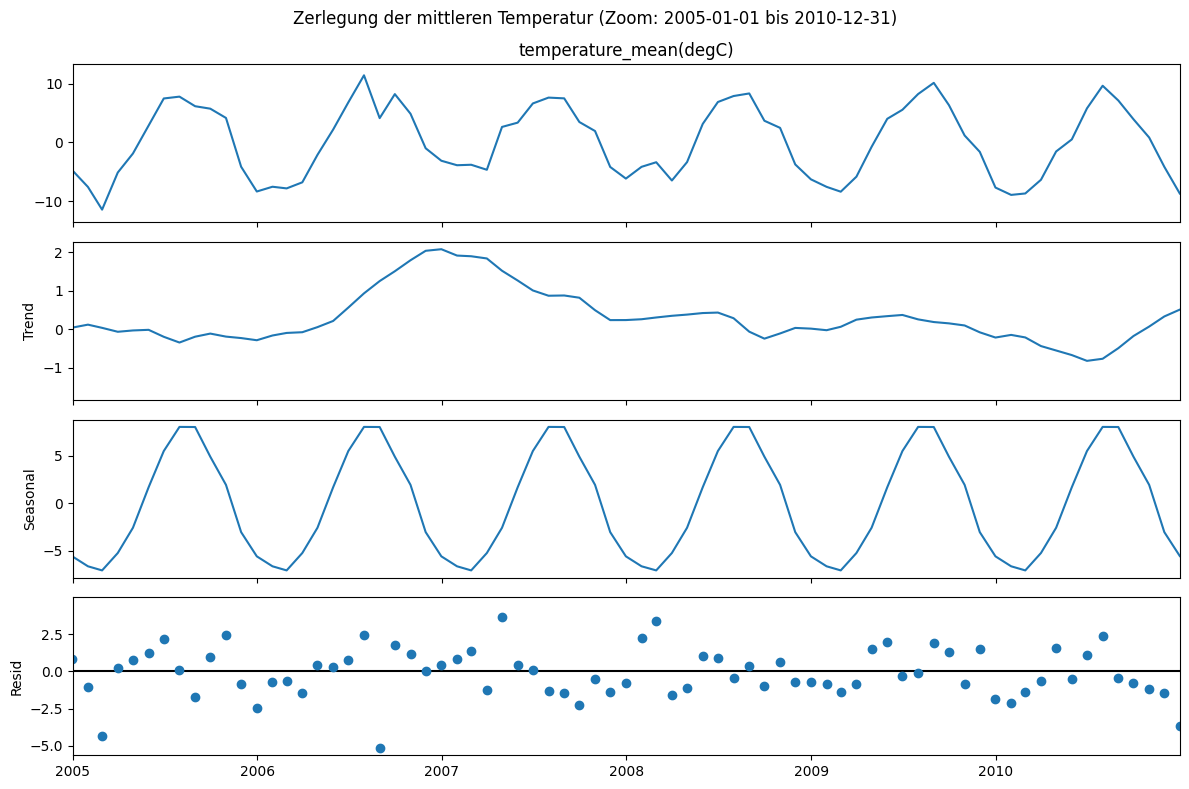

ADF p-Wert der Residuen für 'Zerlegung der mittleren Temperatur': 0.000000
✓ Residuen sind stationaer


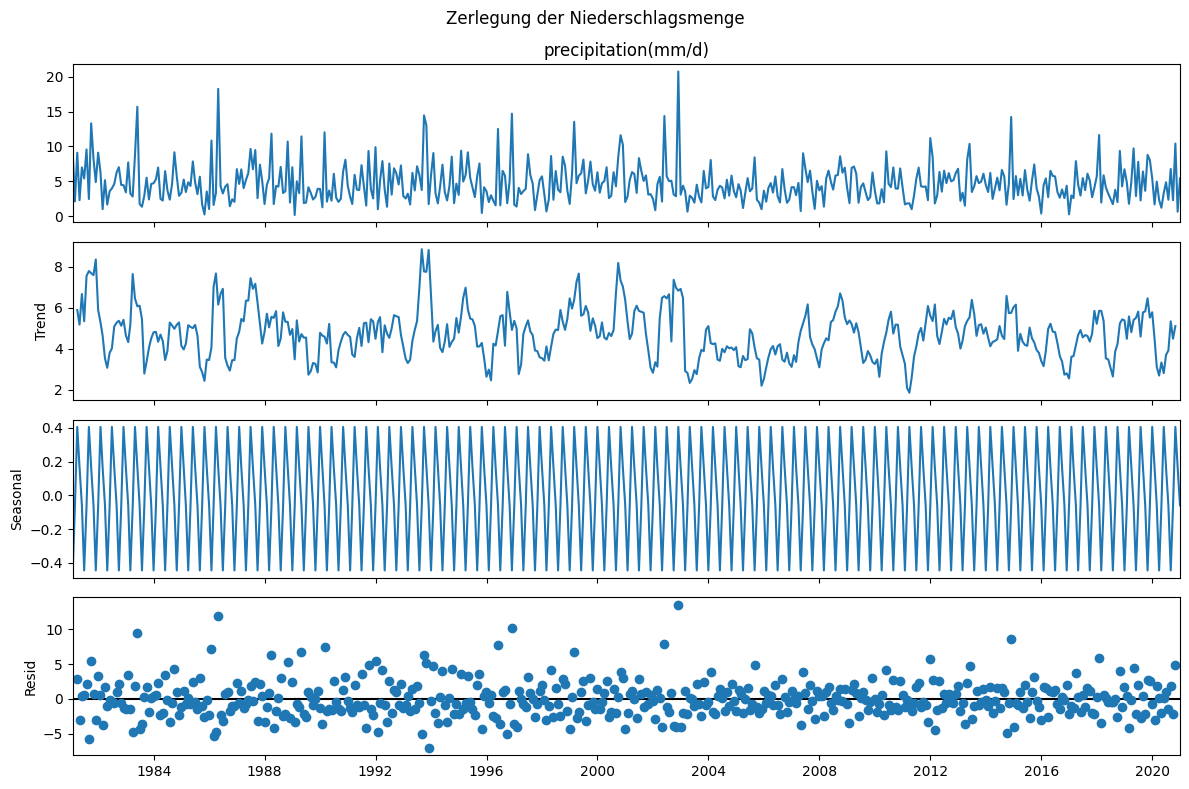

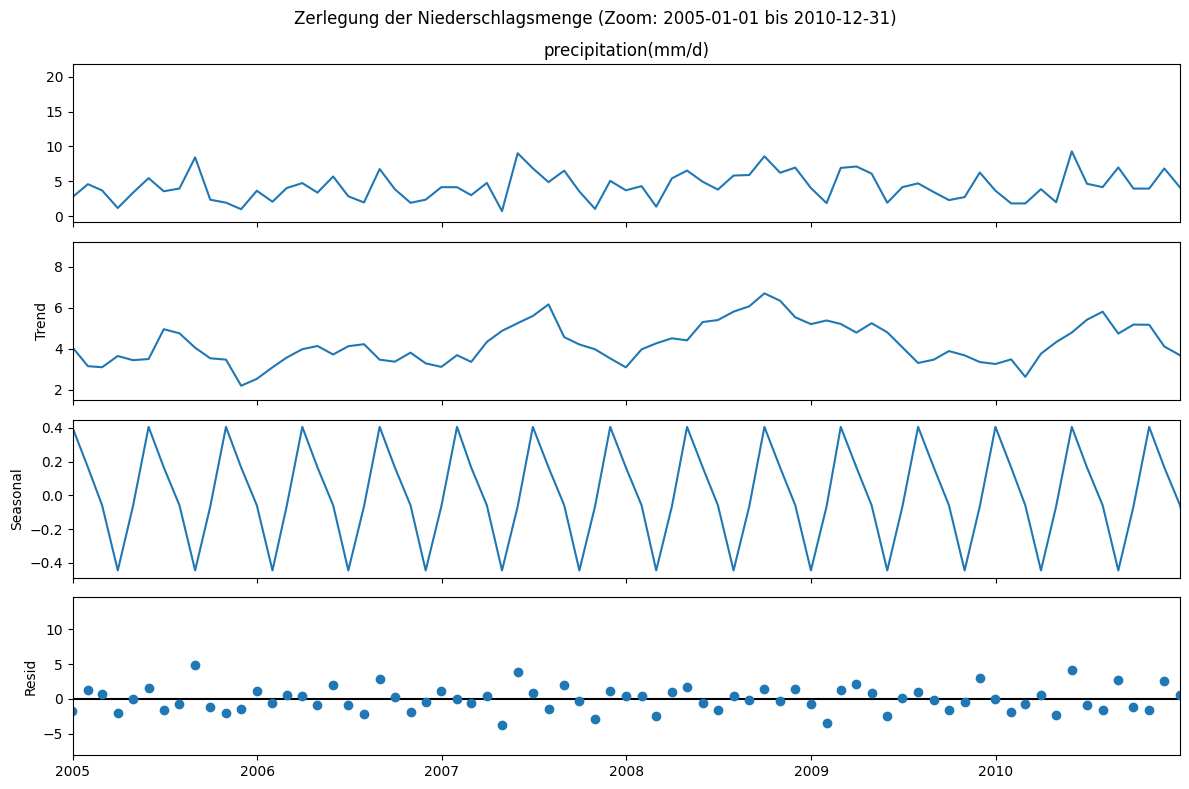

ADF p-Wert der Residuen für 'Zerlegung der Niederschlagsmenge': 0.000000
✓ Residuen sind stationaer


In [128]:
# Seasonale Zerlegung durchführen
df_level_comp_month = seasonal_decompose(df_level_monthly, model='additive', period=12)
df_temp_comp_month = seasonal_decompose(df_temp_monthly, model='additive', period=12)
df_vol_comp_month = seasonal_decompose(df_vol_monthly, model='additive', period=12)
df_percip_comp_month = seasonal_decompose(df_rain_monthly, model='additive', period=5)

# Visualisieren der Zerlegung
def plot_decomposition_zoom(decomp_result, title, start_date='2005-01-01', end_date='2010-12-31'):
    fig = decomp_result.plot()
    fig.suptitle(title)
    fig.set_size_inches(12,8)
    plt.tight_layout()
    plt.show()

    fig = decomp_result.plot()
    fig.suptitle(f"{title} (Zoom: {start_date} bis {end_date})")
    fig.set_size_inches(12,8)
    plt.xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))
    plt.tight_layout()
    plt.show()

    # Berechnen und ausgeben des ADF-Tests der Residuen
    resid = decomp_result.resid.dropna()
    adf_result = adfuller(resid)
    print(f"ADF p-Wert der Residuen für '{title}': {adf_result[1]:.6f}")
    if adf_result[1] < 0.05:
        print("✓ Residuen sind stationaer")
    else:
        print("✗ Residuen nicht stationaer")


dfs_decomposed = (df_level_comp_month, df_vol_comp_month, df_temp_comp_month, df_percip_comp_month)

titles = [
    'Zerlegung des Wasserstands',
    'Zerlegung des Abflussvolumens',
    'Zerlegung der mittleren Temperatur',
    'Zerlegung der Niederschlagsmenge'
]

for decomp, title in zip(dfs_decomposed, titles):
    plot_decomposition_zoom(decomp, title, start_date='2005-01-01', end_date='2010-12-31')

Durch die Aggregation auf Monatsdaten gehen uns natürlich viele Datenpunkte verloren, dadurch wird die Datenbasis kleine und wir können weniger genauere Modelle erstellen. Jedoch ist es so möglich die Regendaten besser zu modellieren. Zu unserem Erstaunen ist es aber so, dass die Regendaten nicht jährlich saisonal sind, sondern eher alle 5 Monate. Die Daten sind laut ADF Test stationär, auch bei Betrachtung der Plots über alle Jahre, sehen die Daten gut aus. Bei den gezoomten Plots sieht man aber leichte Systematiken in den Residuen, welche mit den Saisonalitäten zusammenhängen könnten.

# ACF und PACF Plots der Residuen

Ziel ist es jetzt auch hier zu schauen, wie die ACF und PACF Plots auf den Residuen aussehen und ob wir hier vielleicht auch ARIMA Modelle erstellen können.

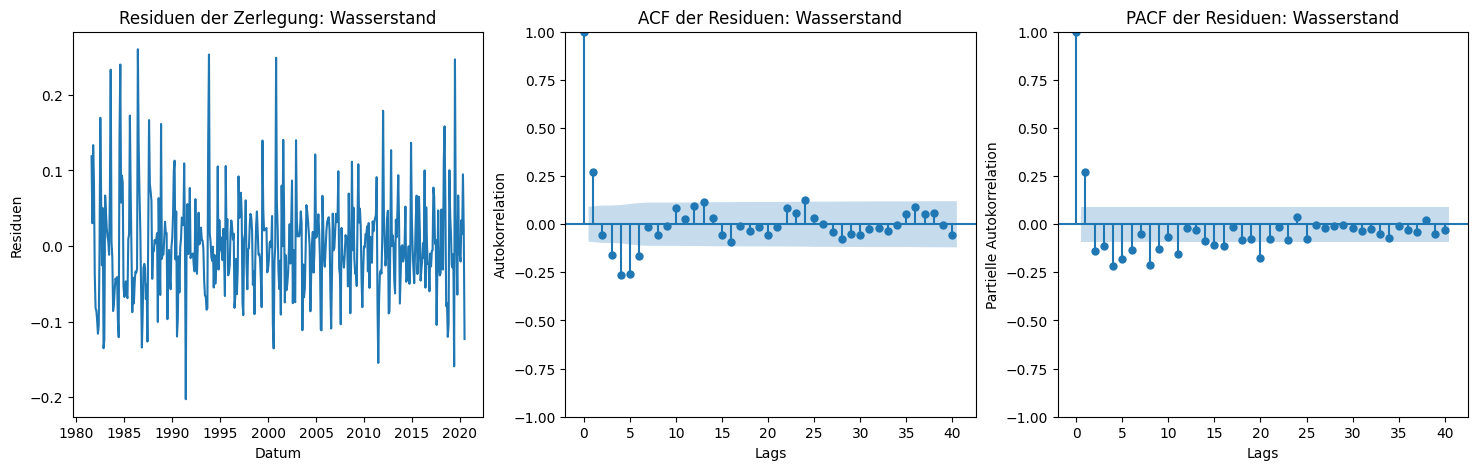

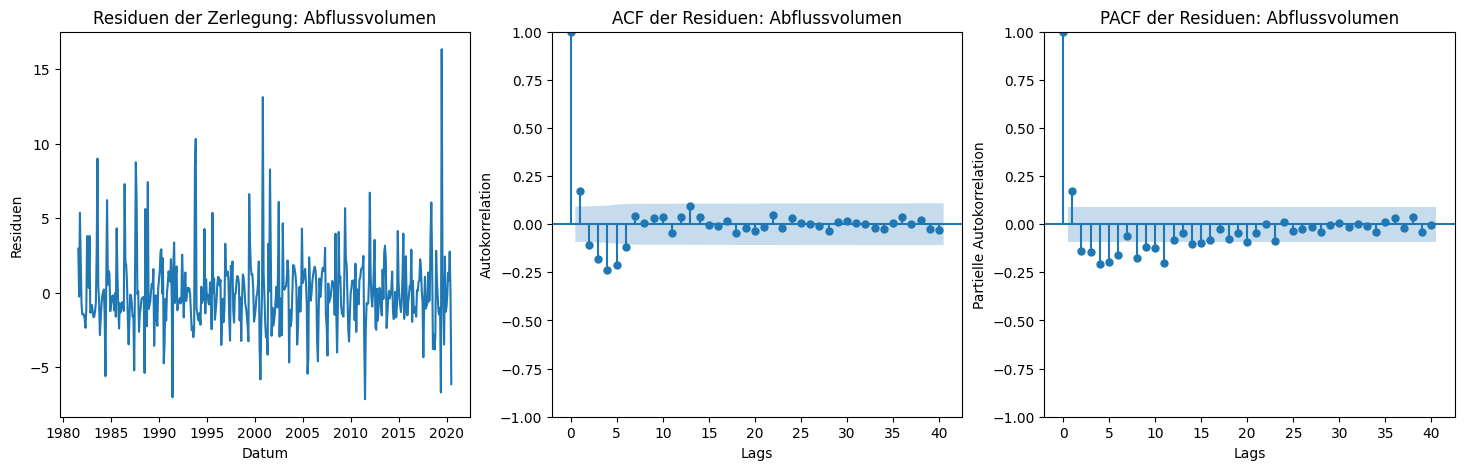

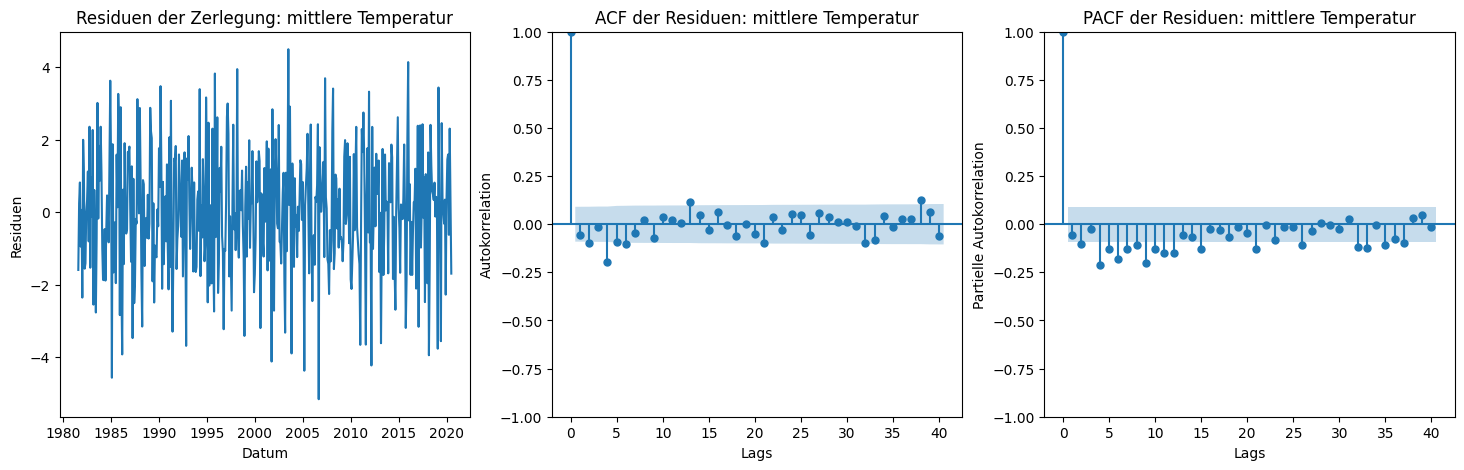

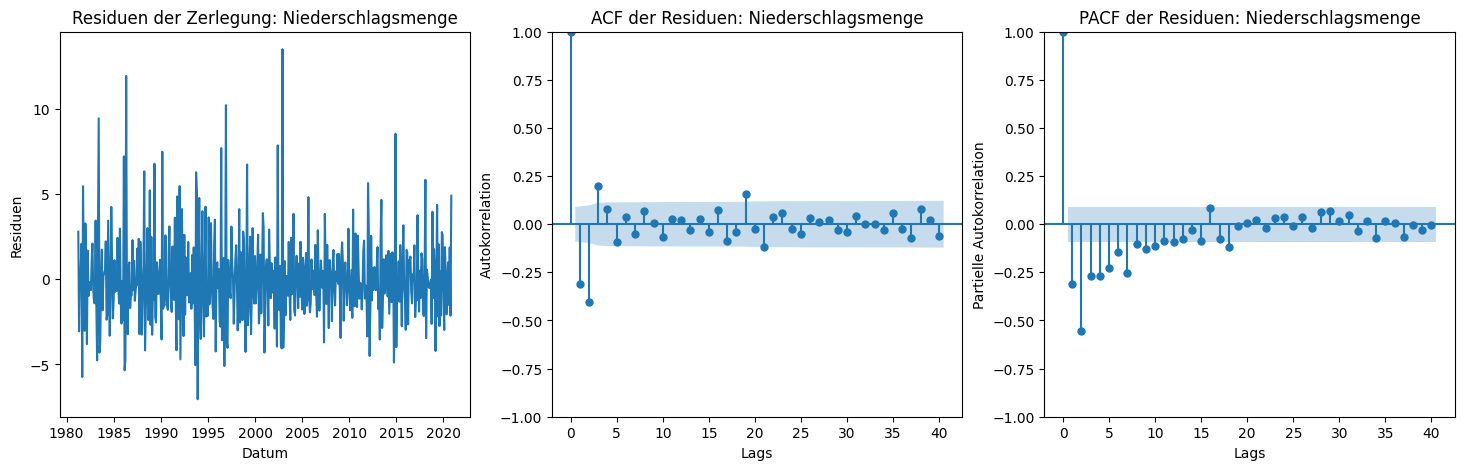

In [129]:
def acf_pacf_plots_decomposed(resid, title):
    # Plot Residuen
    plt.figure(figsize=(18,5))
    plt.subplot(1,3,1)
    plt.plot(resid)
    plt.title(f'Residuen der Zerlegung: {title}')
    plt.xlabel('Datum')
    plt.ylabel('Residuen')

    # ACF Plot
    plt.subplot(1,3,2)
    plot_acf(resid, ax=plt.gca(), lags=40)
    plt.title(f'ACF der Residuen: {title}')
    plt.xlabel('Lags')
    plt.ylabel('Autokorrelation')

    # PACF Plot
    plt.subplot(1,3,3)
    plot_pacf(resid, ax=plt.gca(), lags=40)
    plt.title(f'PACF der Residuen: {title}')
    plt.xlabel('Lags')
    plt.ylabel('Partielle Autokorrelation')
    plt.show()

dfs_decomposed = (df_level_comp_month, df_vol_comp_month, df_temp_comp_month, df_percip_comp_month)

titles = [
    'Wasserstand',
    'Abflussvolumen',
    'mittlere Temperatur',
    'Niederschlagsmenge'
]

for decomp, title in zip(dfs_decomposed, titles):
    resid = decomp.resid.dropna()
    acf_pacf_plots_decomposed(resid, title)

Auf den Plots ist ersichtlich, wie eine Modellierung der Residuen mit ARIMA Modellen möglich sein könnte. Bei den Wasserständen zeigt die ACF eine schwankende Abnahme, während die PACF nach dem ersten Lag abrupt abfällt und dann negativ unter dem Signifikanzniveau bleibt bis auf 20 Lags. Dadurch könnte ein AR(20) Modell in Frage kommen.  
Beim Abflussvolumen zeigt die ACF ebenfalls eine schwankende Abnahme, während die PACF nach dem ersten Lag ebenfalls abrupt abfällt und dann negativ unter dem Signifikanzniveau bleibt bis auf 20 Lags. Auch hier könnte ein AR(20) Modell in Frage kommen.  
Die mittlere Temperatur sieht etwas anders aus, auch hier schwankt die ACF ab, aber die PACF fällt direkt nach dem ersten Lag ab und bleibt dann sehr lange negativ ausserhalb des Signifikanzniveaus. Hier könnte ein AR(37) Modell in frage kommen.  
Bei den Regendaten ist sowohl die ACF als auch die PACF nicht klar abfallend. Wahrscheinlich ist aber eher eine MA Komponente hier sinnvoll, da die PACF einigermassen zu null geht. Hier könnte ein MA(3) oder MA(20) Modell in Frage kommen.

Die Werte für die AR und MA Komponente sind teilweise sehr hoch, da es in den ACF und PACF Plots jeweils Punkte gibt die knapp über dem Signifikanzniveau liegen. Hier wird müssen wir sicherlich noch schauen, ob diese Werte sinnvoll sind oder ob wir die Modelle mit kleineren Werten besser hinbekommen.

# Modellierung der Daten
Nun versuchen wir die dekomponierten Daten jeweils zu modellieren und sie wieder möglichst genau zusammenzuführen und Vorhersagen zu machen. Um zu testen wie gut die Vorhersagen sind, nutzen wir ein Testset, welches auf den letzten Jahren des Datensets basiert.

In [130]:
# Umwandeln der decomposed Objekte in DataFrames
def decomposed_to_df(decomp):
    df = pd.DataFrame({
        'observed': decomp.observed,
        'trend': decomp.trend,
        'seasonal': decomp.seasonal,
        'resid': decomp.resid
    })
    return df

df_level_monthly_decomp = decomposed_to_df(df_level_comp_month)
df_temp_monthly_decomp = decomposed_to_df(df_temp_comp_month)
df_vol_monthly_decomp = decomposed_to_df(df_vol_comp_month)
df_rain_monthly_decomp = decomposed_to_df(df_percip_comp_month)

# Alles in ein DataFrame zusammenführen
df_monthly_decomp = pd.DataFrame({
    'level_obs': df_level_monthly_decomp['observed'],
    'level_trend': df_level_monthly_decomp['trend'],
    'level_seasonal': df_level_monthly_decomp['seasonal'],
    'level_resid': df_level_monthly_decomp['resid'],
    'vol_obs': df_vol_monthly_decomp['observed'],
    'vol_trend': df_vol_monthly_decomp['trend'],
    'vol_seasonal': df_vol_monthly_decomp['seasonal'],
    'vol_resid': df_vol_monthly_decomp['resid'],
    'temp_obs': df_temp_monthly_decomp['observed'],
    'temp_trend': df_temp_monthly_decomp['trend'],
    'temp_seasonal': df_temp_monthly_decomp['seasonal'],
    'temp_resid': df_temp_monthly_decomp['resid'],
    'rain_obs': df_rain_monthly_decomp['observed'],
    'rain_trend': df_rain_monthly_decomp['trend'],
    'rain_seasonal': df_rain_monthly_decomp['seasonal'],
    'rain_resid': df_rain_monthly_decomp['resid']
})
# Löschen von NaN-Werten
df_monthly_decomp.dropna(inplace=True)

# Train und Test Set erstellen
split_date = '2018-06-01'
df_train = df_monthly_decomp[df_monthly_decomp.index < split_date]
df_test = df_monthly_decomp[df_monthly_decomp.index >= split_date]

## Vorhersage der Wasserstände
### Trend der Wasserstände

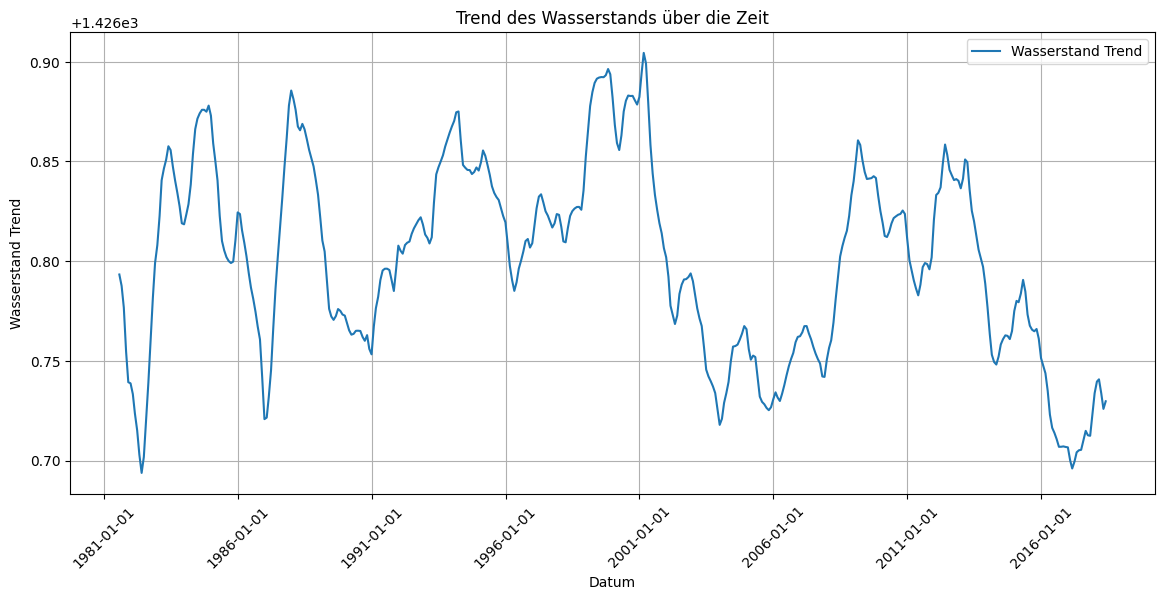

In [131]:
# Trend des Wasserstands modellieren
# Anzeigen des Trends (Datum nur alle 5 Jahre)
xticks = pd.date_range(
    start=df_train.index.min().replace(month=1, day=1),
    end=df_train.index.max(),
    freq='5YS'   # 5-year start frequency
)

plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['level_trend'], label='Wasserstand Trend')
plt.xlabel('Datum')
plt.ylabel('Wasserstand Trend')
plt.title('Trend des Wasserstands über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

Den Trend könnten wir entweder mit einer Linearen Regression modellieren, oder mit einem ARIMA Modell. Da der Trend aber nicht linear aussieht, versuchen wir es hier mit einem ARIMA Modell. Dazu wird zuerst die ACF und PACF der Trend Komponente geplottet, um mögliche Parameter für das ARIMA Modell zu bestimmen.

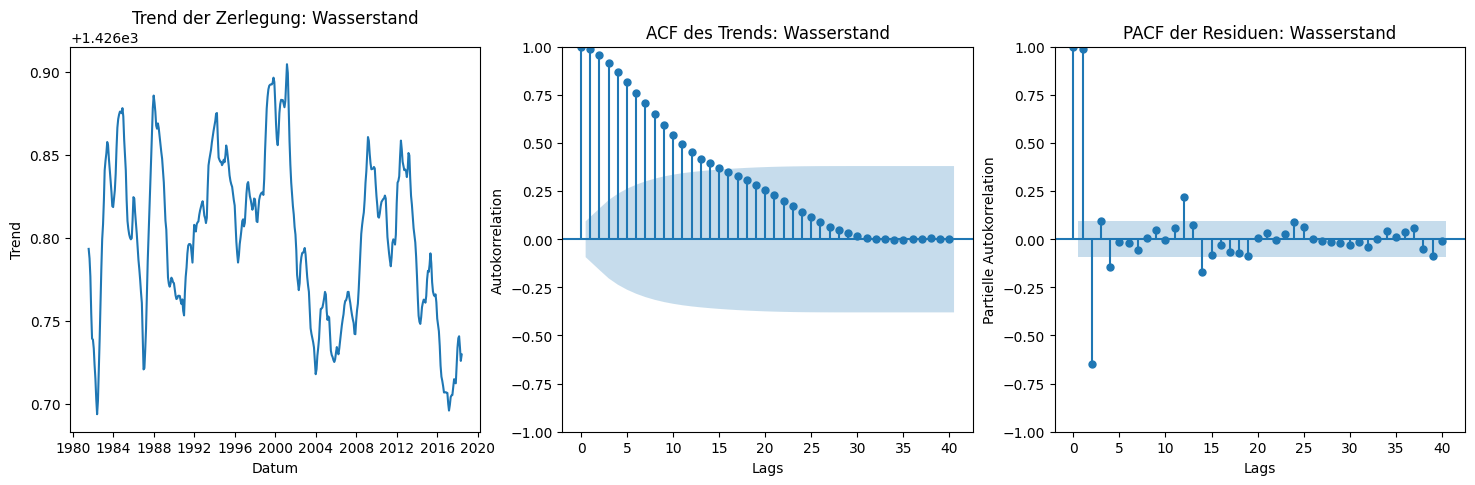

In [132]:
def acf_pacf_plots_decomposed(resid, title):
    # Plot Residuen
    plt.figure(figsize=(18,5))
    plt.subplot(1,3,1)
    plt.plot(resid)
    plt.title(f'Trend der Zerlegung: {title}')
    plt.xlabel('Datum')
    plt.ylabel('Trend')

    # ACF Plot
    plt.subplot(1,3,2)
    plot_acf(resid, ax=plt.gca(), lags=40)
    plt.title(f'ACF des Trends: {title}')
    plt.xlabel('Lags')
    plt.ylabel('Autokorrelation')

    # PACF Plot
    plt.subplot(1,3,3)
    plot_pacf(resid, ax=plt.gca(), lags=40)
    plt.title(f'PACF der Residuen: {title}')
    plt.xlabel('Lags')
    plt.ylabel('Partielle Autokorrelation')
    plt.show()

acf_pacf_plots_decomposed(df_train['level_trend'].dropna(), 'Wasserstand')

Aus dem ACF und PACF Plot des Trends der Wasserstände, könnten wir ein AR(2) oder AR(14) Modell in betracht ziehen. Wir probieren hier zuerst nur das AR(2) Modell aus. Da dies wahrscheinlich reicht um den Trend zu modellieren.

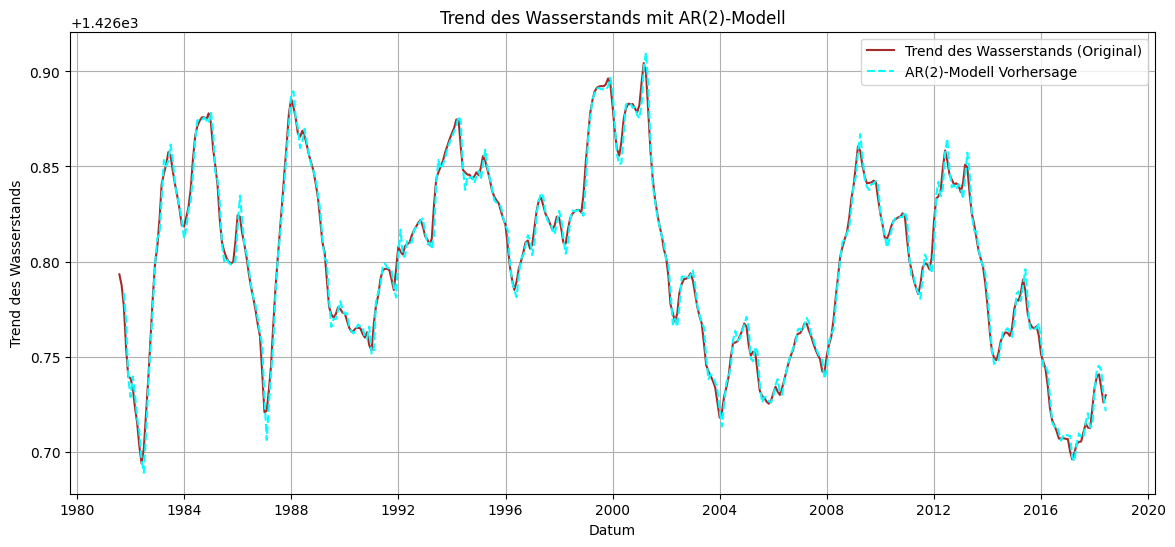

In [133]:
# AR(2) Modell für den Trend des Wasserstands fitten
from statsmodels.tsa.ar_model import AutoReg
level_trend_model = AutoReg(df_train['level_trend'].dropna(), lags=2).fit()
level_trend_pred = level_trend_model.fittedvalues
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['level_trend'], label='Trend des Wasserstands (Original)', color='brown')
plt.plot(level_trend_pred.index, level_trend_pred, label='AR(2)-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Trend des Wasserstands')
plt.title('Trend des Wasserstands mit AR(2)-Modell')
plt.grid(True)
plt.legend()
plt.show()

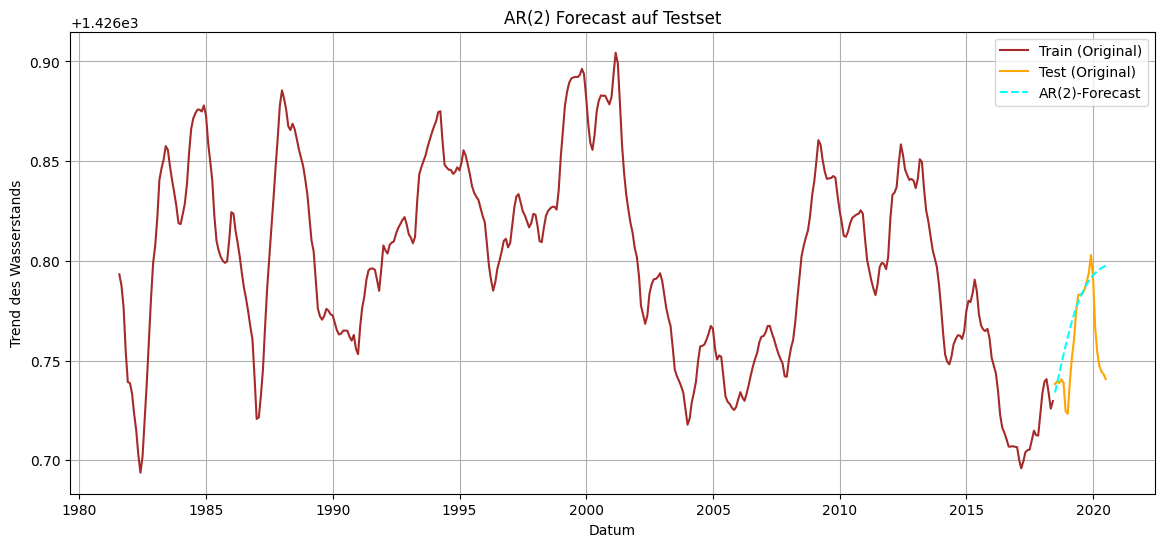

In [134]:
n_test = len(df_test)

level_trend_forecast = level_trend_model.predict(
    start=len(df_train),
    end=len(df_train) + n_test - 1
)

level_trend_forecast.index = df_test.index

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['level_trend'], 
         label='Train (Original)', color='brown')

# Test (Ground Truth)
plt.plot(df_test.index, df_test['level_trend'], 
         label='Test (Original)', color='orange')

# Forecast
plt.plot(df_test.index, level_trend_forecast, 
         label='AR(2)-Forecast', color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Trend des Wasserstands')
plt.title('AR(2) Forecast auf Testset')
plt.grid(True)
plt.legend()
plt.show()

Man sieht, dass die Prediction für den Trend der Wasserstände zuerst eine falsche Prediction macht und danach etwa auf der Höhe bleibt. Dies liegt daran, dass nach 2 Lags die Werte nicht mehr berücksichtigt werden. Dadurch ist das Modell nicht in der Lage den Trend langfristig zu verfolgen. Wir haben als Experiment noch ein AR(14) Modell ausprobiert, welches aber auch nicht wirklich besser war, da der initiale Fehler in der Abschätzung des ersten Punktes im Testset bestehen bleibt.

### Saisonalität der Wasserstände

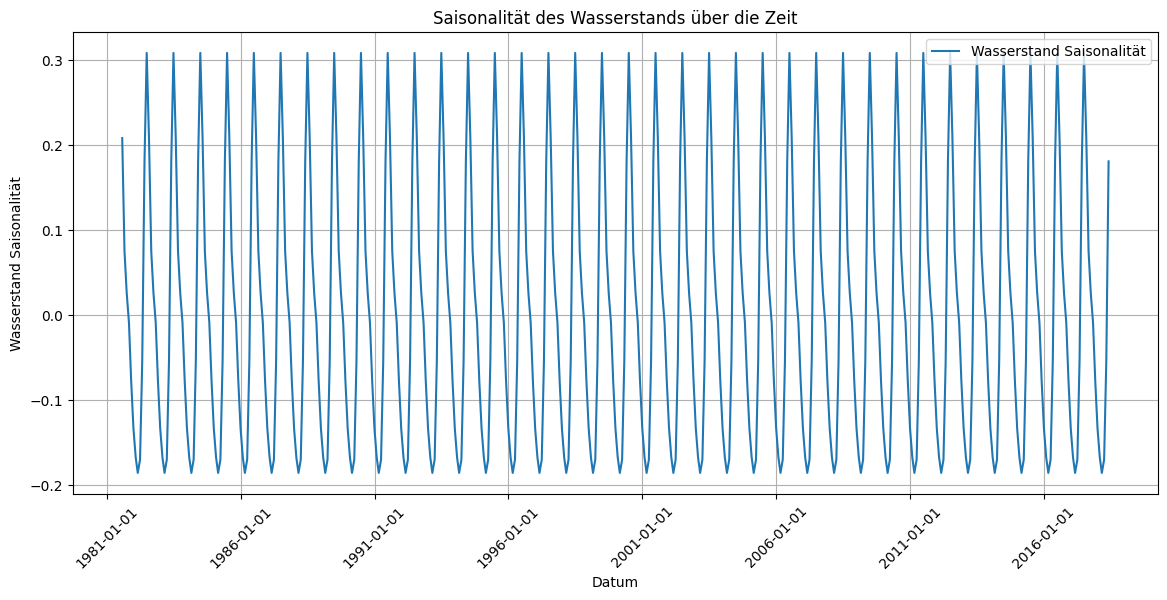

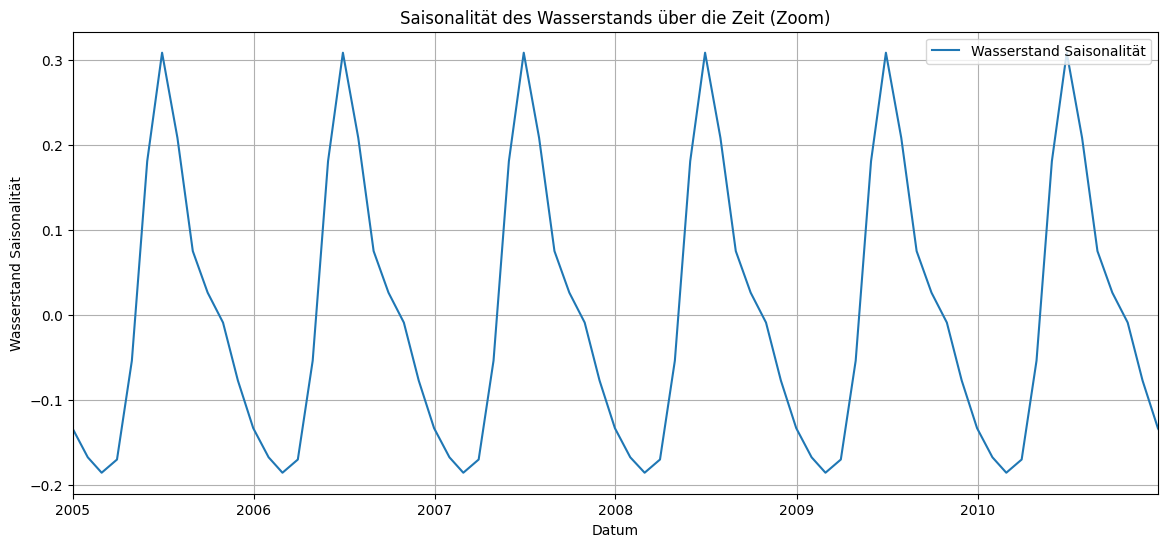

In [135]:
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['level_seasonal'], label='Wasserstand Saisonalität')
plt.xlabel('Datum')
plt.ylabel('Wasserstand Saisonalität')
plt.title('Saisonalität des Wasserstands über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

# Zoom in die Saisonalität
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['level_seasonal'], label='Wasserstand Saisonalität')
plt.xlabel('Datum')
plt.ylabel('Wasserstand Saisonalität')
plt.title('Saisonalität des Wasserstands über die Zeit (Zoom)')
plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2010-12-31'))
plt.grid(True)
plt.legend()
plt.show()

Da die Saisonalität immer wiederholt wird, können wir diese einfach aus dem Trainingsset übernehmen und für die Vorhersage im Testset nutzen. Dies funktioniert hier sehr gut, da die Saisonalität der Wasserstände über die Jahre sehr konstant ist.

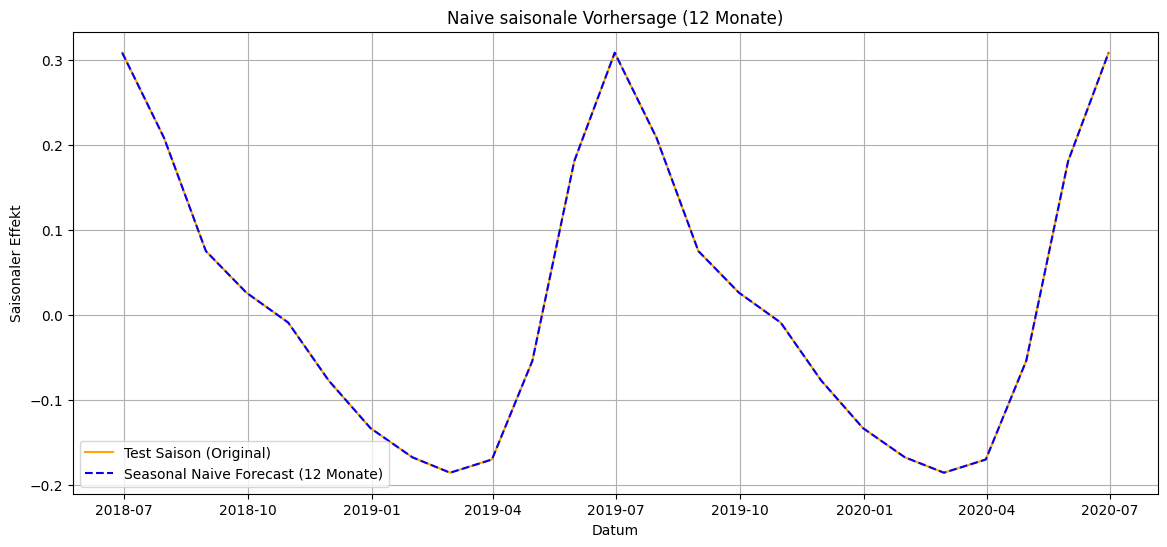

In [136]:
season_length = 12  # Monate in einer Saison

last_season = df_train['level_seasonal'].iloc[-season_length:]

n_test = len(df_test)

season_level_forecast = np.tile(
    last_season.values,
    int(np.ceil(n_test / season_length))
)[:n_test]

season_level_forecast = pd.Series(
    season_level_forecast,
    index=df_test.index,
    name='season_naive_forecast'
)

plt.figure(figsize=(14, 6))

plt.plot(df_test.index, df_test['level_seasonal'], 
         label='Test Saison (Original)', color='orange')

plt.plot(season_level_forecast.index, season_level_forecast, 
         label='Seasonal Naive Forecast (12 Monate)', 
         color='blue', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Saisonaler Effekt')
plt.title('Naive saisonale Vorhersage (12 Monate)')
plt.grid(True)
plt.legend()
plt.show()

Man sieht das die Saisonalität der Wasserstände durch die Vorherigen Werte sehr gut modelliert werden kann.

### Residuen der Wasserstände
Hierbei haben wir schon im Vorhinein gesehen, dass ein AR(20) Modell in Frage kommen könnte. Wir probieren dies hier aus.

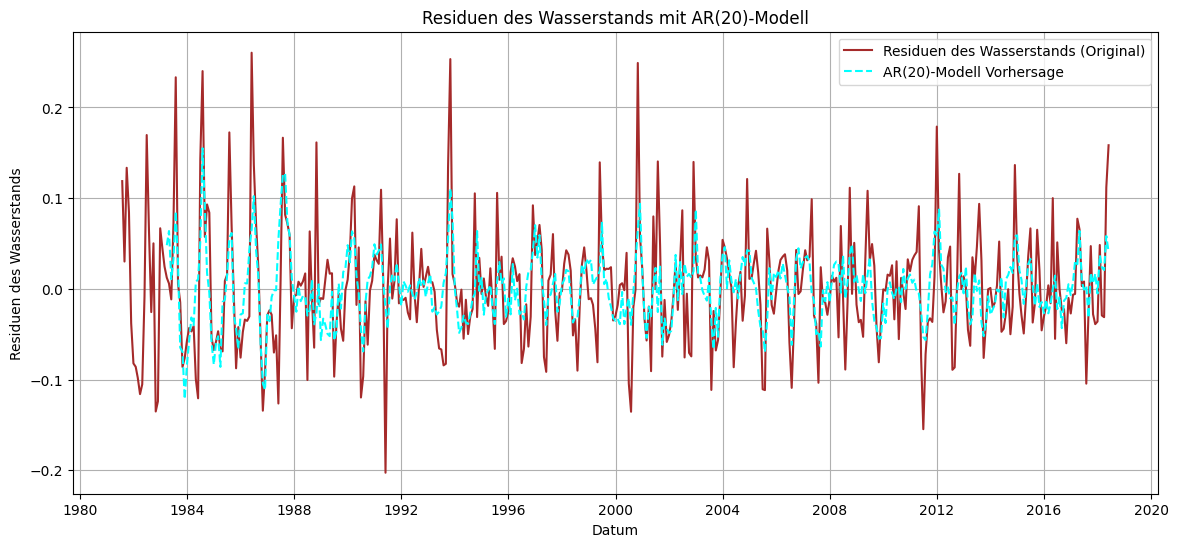

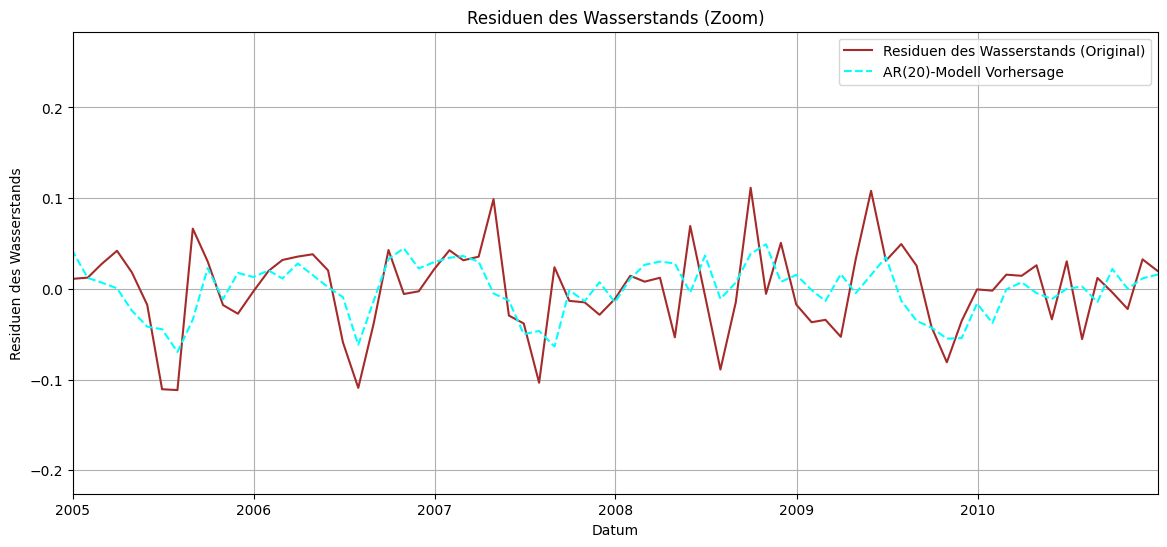

In [137]:
# AR(20) Modell für die Residuen des Wasserstands fitten
level_resid_model = AutoReg(df_train['level_resid'].dropna(), lags=20).fit()
level_resid_pred = level_resid_model.fittedvalues
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['level_resid'], label='Residuen des Wasserstands (Original)', color='brown')
plt.plot(level_resid_pred.index, level_resid_pred, label='AR(20)-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Residuen des Wasserstands')
plt.title('Residuen des Wasserstands mit AR(20)-Modell')
plt.grid(True)
plt.legend()
plt.show()

# Zoom in die Residuen
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['level_resid'], label='Residuen des Wasserstands (Original)', color='brown')
plt.plot(level_resid_pred.index, level_resid_pred, label='AR(20)-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Residuen des Wasserstands')
plt.title('Residuen des Wasserstands (Zoom)')
plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2010-12-31'))
plt.grid(True)
plt.legend()
plt.show()

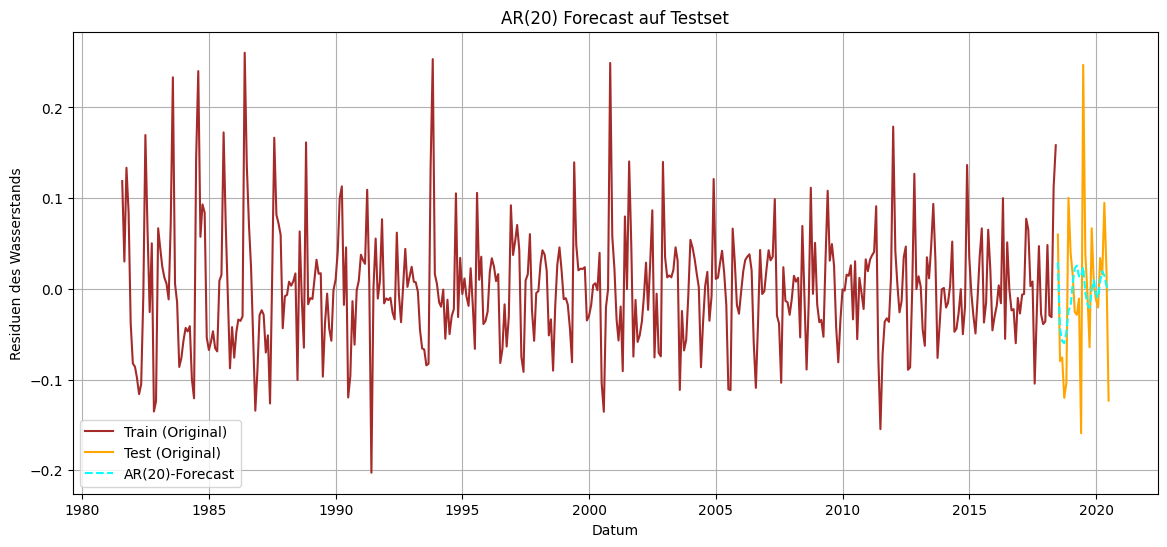

In [138]:
n_test = len(df_test)

level_resid_forecast = level_resid_model.predict(
    start=len(df_train),
    end=len(df_train) + n_test - 1
)

level_resid_forecast.index = df_test.index

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['level_resid'], 
         label='Train (Original)', color='brown')

# Test (Ground Truth)
plt.plot(df_test.index, df_test['level_resid'], 
         label='Test (Original)', color='orange')

# Forecast
plt.plot(df_test.index, level_resid_forecast, 
         label='AR(20)-Forecast', color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Residuen des Wasserstands')
plt.title('AR(20) Forecast auf Testset')
plt.grid(True)
plt.legend()
plt.show()

Der Forecast der Residuen mit dem AR(20) Modell sieht nur so mässig gut aus. Man sieht bereits im Plot auf den Trainingsdaten, dass das Modell die Residuen nicht sehr gut modellieren kann. Dadurch ist der Forecast auf dem Testset auch nicht sehr gut. Auch hier sieht man, dass der Forecast nach einiger Zeit stark abflacht, was daran liegt, dass nur die ersten 20 Lags berücksichtigt werden. Dadurch ist das Modell nicht in der Lage die Residuen langfristig zu verfolgen.

### Zusammenführung der Vorhersagen
Nun fügen wir die Vorhersagen der einzelnen Komponenten wieder zusammen, um die finalen Vorhersagen für die Wasserstände zu erhalten.

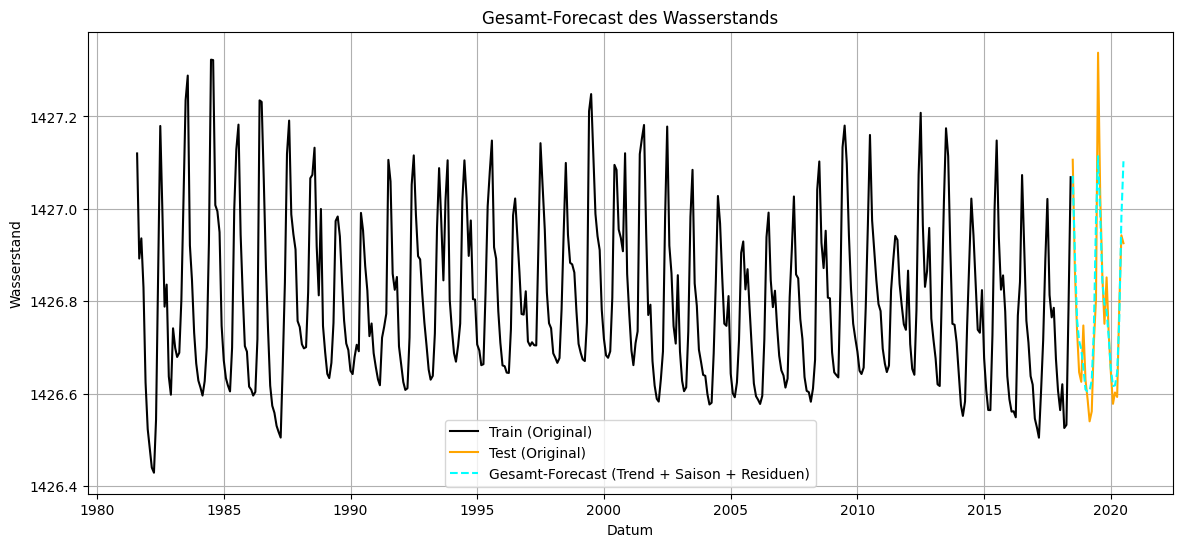

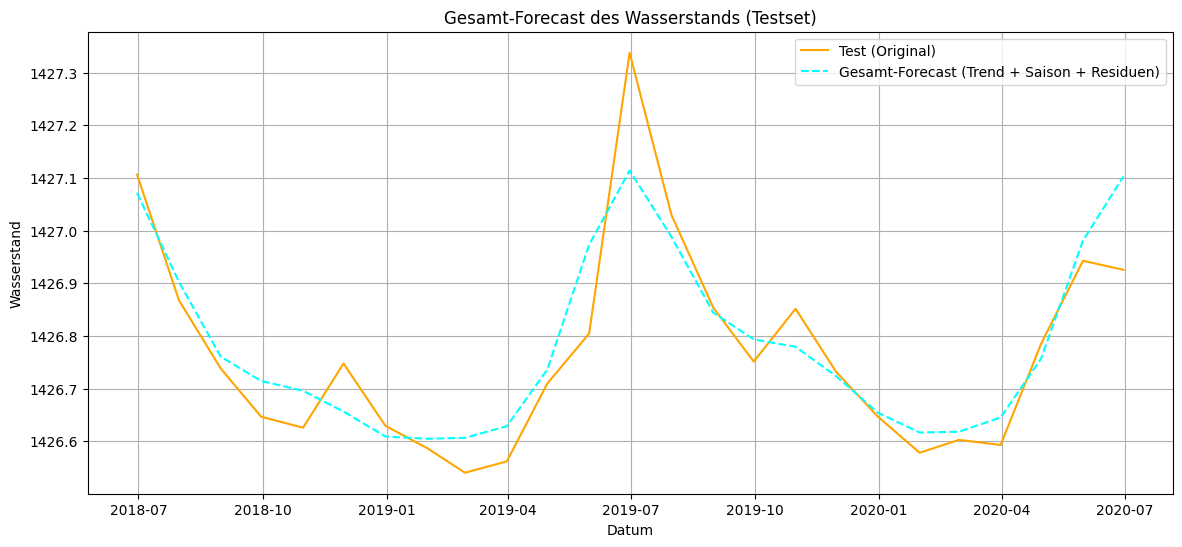

RMSE: 0.0063
MAE:  0.0577


In [139]:
level_forecast_total = (
    level_trend_forecast
    + season_level_forecast
    + level_resid_forecast
)

level_forecast_total.name = 'level_forecast'

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['level_obs'],
         label='Train (Original)', color='black')

# Test
plt.plot(df_test.index, df_test['level_obs'],
         label='Test (Original)', color='orange')

# Forecast
plt.plot(level_forecast_total.index, level_forecast_total,
         label='Gesamt-Forecast (Trend + Saison + Residuen)',
         color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Wasserstand')
plt.title('Gesamt-Forecast des Wasserstands')
plt.grid(True)
plt.legend()
plt.show()

# Zoom nur auf das Testset
plt.figure(figsize=(14, 6))
plt.plot(df_test.index, df_test['level_obs'],
         label='Test (Original)', color='orange')
plt.plot(level_forecast_total.index, level_forecast_total,
         label='Gesamt-Forecast (Trend + Saison + Residuen)', 
            color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Wasserstand')
plt.title('Gesamt-Forecast des Wasserstands (Testset)')
plt.grid(True)
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = mean_squared_error(df_test['level_obs'], level_forecast_total)
mae = mean_absolute_error(df_test['level_obs'], level_forecast_total)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

Der Forecast für den Wasserstand sieht insgesamt gut aus. Es ist klar zu sehen, dass der grosse Teil durch die Saisonalität abgedeckt wird, welche wir direkt aus dem Trainingsset übernommen haben.

## Vorhersage des Abflussvolumens
Da diese sehr ähnlich zu den Wasserständen sind, versuchen wir hier die gleichen Modelle wie bei den Wasserständen und führen die Ergebnisse etwas weniger ausführlich auf.
### Trend des Abflussvolumens

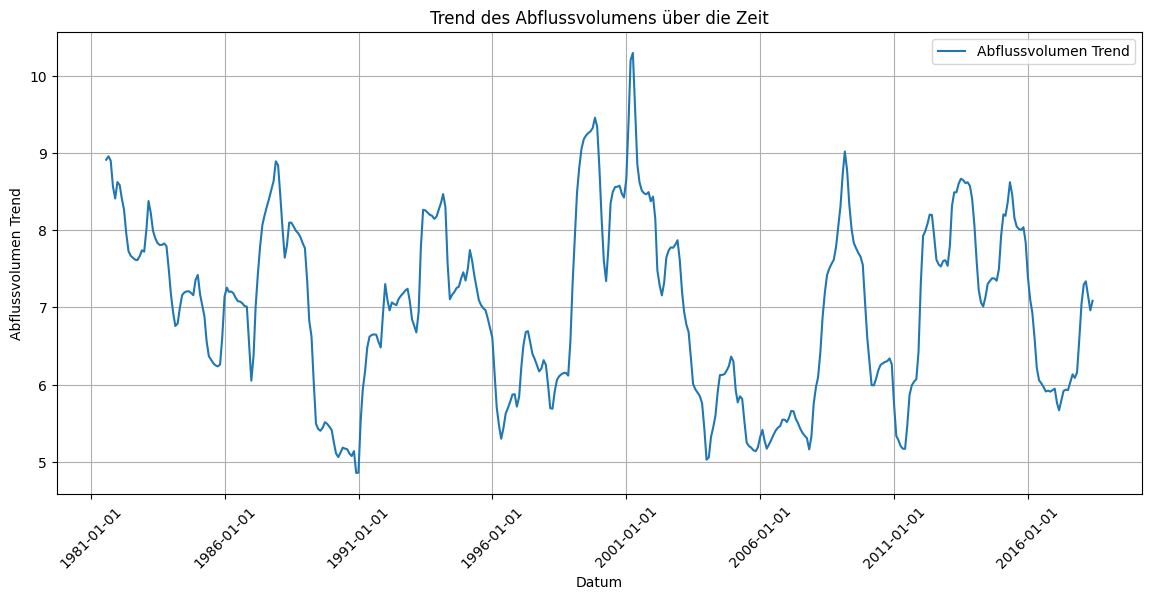

In [140]:
# Trend der Temperatur modellieren
# Anzeigen des Trends (Datum nur alle 5 Jahre)
xticks = pd.date_range(
    start=df_train.index.min().replace(month=1, day=1),
    end=df_train.index.max(),
    freq='5YS'   # 5-year start frequency
)

plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['vol_trend'], label='Abflussvolumen Trend')
plt.xlabel('Datum')
plt.ylabel('Abflussvolumen Trend')
plt.title('Trend des Abflussvolumens über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

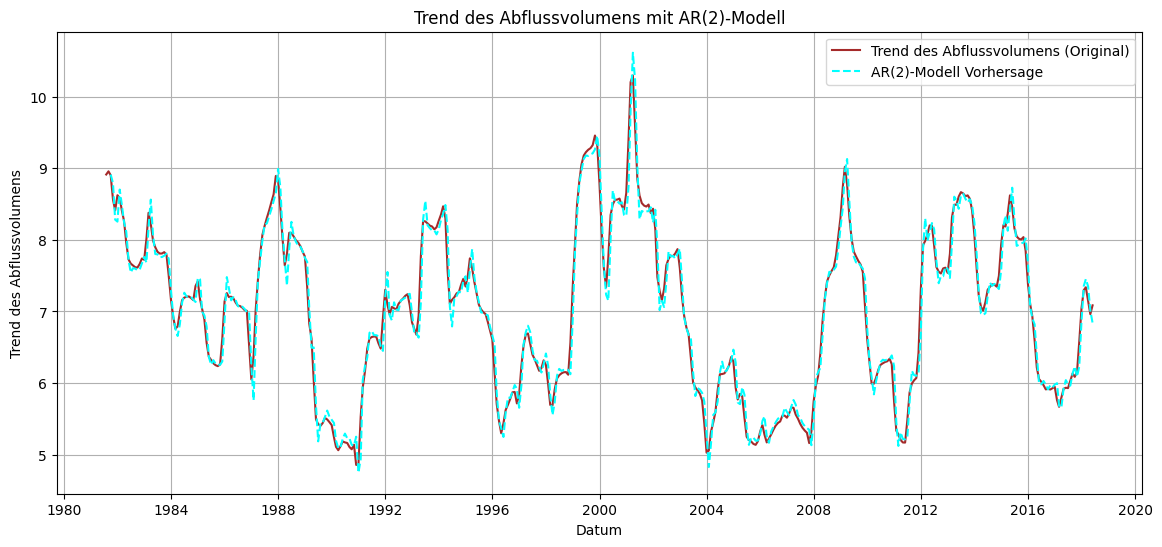

In [141]:
# AR(2) Modell für den Trend des Abflussvolumens fitten
vol_trend_model = AutoReg(df_train['vol_trend'].dropna(), lags=2).fit()
vol_trend_pred = vol_trend_model.fittedvalues
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['vol_trend'], label='Trend des Abflussvolumens (Original)', color='brown')
plt.plot(vol_trend_pred.index, vol_trend_pred, label='AR(2)-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Trend des Abflussvolumens')
plt.title('Trend des Abflussvolumens mit AR(2)-Modell')
plt.grid(True)
plt.legend()
plt.show()

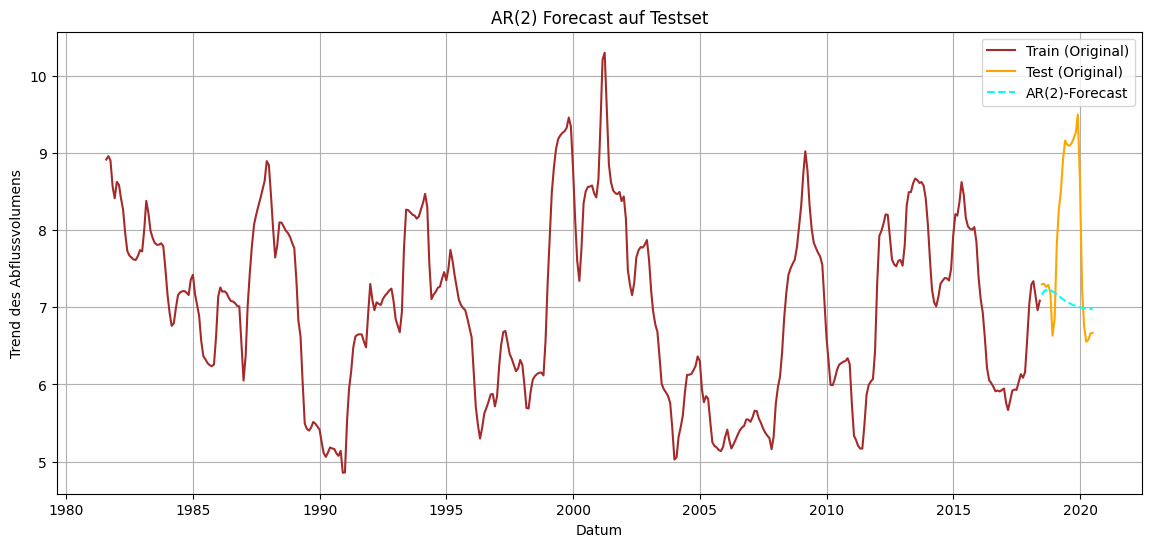

In [142]:
n_test = len(df_test)

vol_trend_forecast = vol_trend_model.predict(
    start=len(df_train),
    end=len(df_train) + n_test - 1
)

vol_trend_forecast.index = df_test.index

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['vol_trend'], 
         label='Train (Original)', color='brown')

# Test (Ground Truth)
plt.plot(df_test.index, df_test['vol_trend'], 
         label='Test (Original)', color='orange')

# Forecast
plt.plot(df_test.index, vol_trend_forecast, 
         label='AR(2)-Forecast', color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Trend des Abflussvolumens')
plt.title('AR(2) Forecast auf Testset')
plt.grid(True)
plt.legend()
plt.show()

### Saisonalität des Abflussvolumens

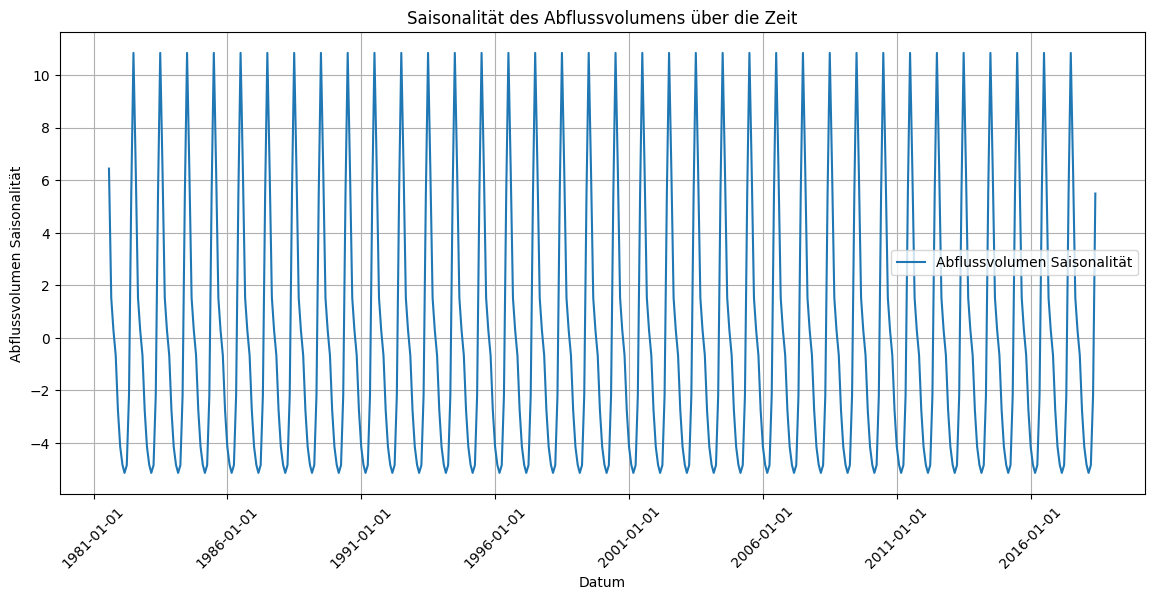

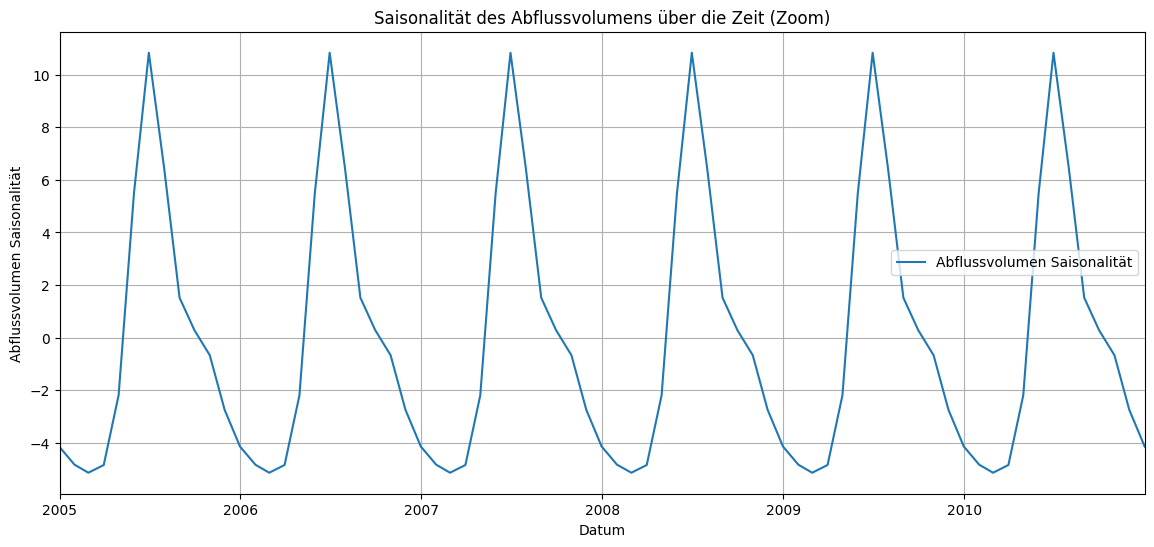

In [143]:
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['vol_seasonal'], label='Abflussvolumen Saisonalität')
plt.xlabel('Datum')
plt.ylabel('Abflussvolumen Saisonalität')
plt.title('Saisonalität des Abflussvolumens über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

# Zoom in die Saisonalität
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['vol_seasonal'], label='Abflussvolumen Saisonalität')
plt.xlabel('Datum')
plt.ylabel('Abflussvolumen Saisonalität')
plt.title('Saisonalität des Abflussvolumens über die Zeit (Zoom)')
plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2010-12-31'))
plt.grid(True)
plt.legend()
plt.show()

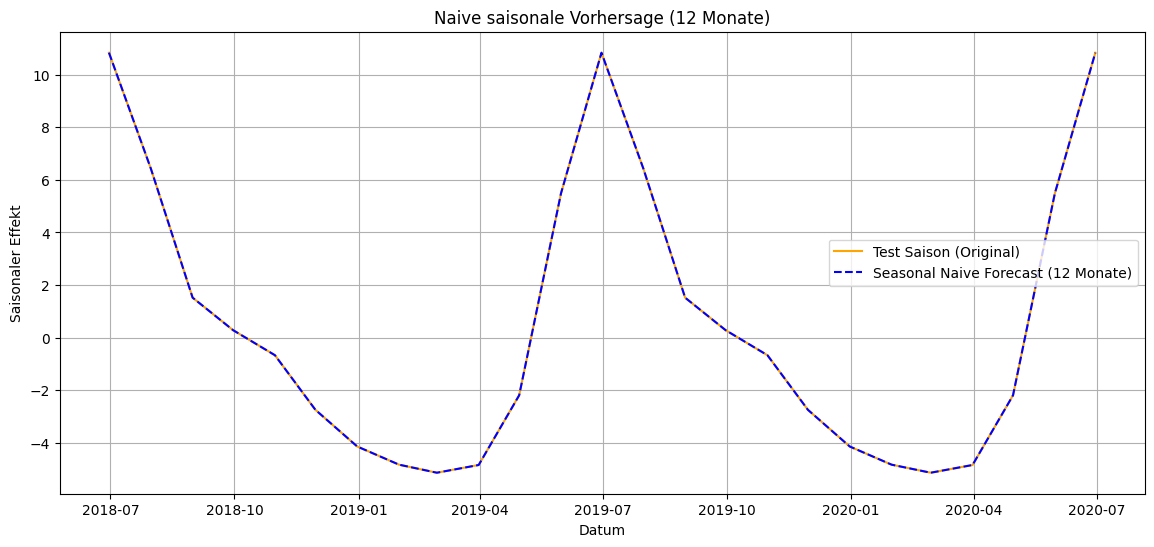

In [144]:
season_length = 12  # Monate in einer Saison

last_season = df_train['vol_seasonal'].iloc[-season_length:]

n_test = len(df_test)

season_vol_forecast = np.tile(
    last_season.values,
    int(np.ceil(n_test / season_length))
)[:n_test]

season_vol_forecast = pd.Series(
    season_vol_forecast,
    index=df_test.index,
    name='season_naive_forecast'
)

plt.figure(figsize=(14, 6))

plt.plot(df_test.index, df_test['vol_seasonal'], 
         label='Test Saison (Original)', color='orange')

plt.plot(season_vol_forecast.index, season_vol_forecast, 
         label='Seasonal Naive Forecast (12 Monate)', 
         color='blue', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Saisonaler Effekt')
plt.title('Naive saisonale Vorhersage (12 Monate)')
plt.grid(True)
plt.legend()
plt.show()

### Residuen des Abflussvolumens

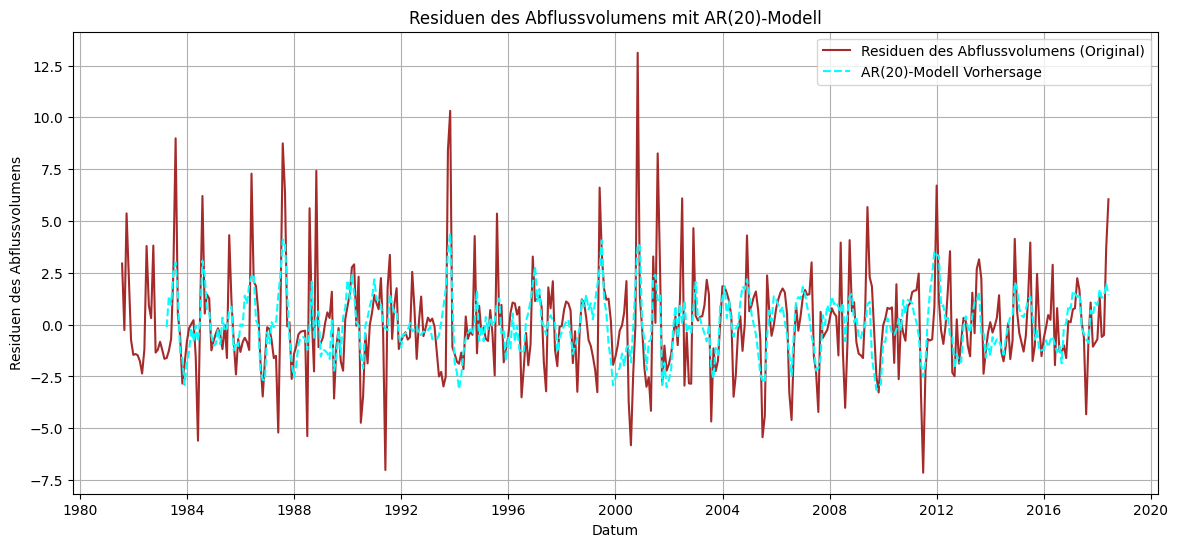

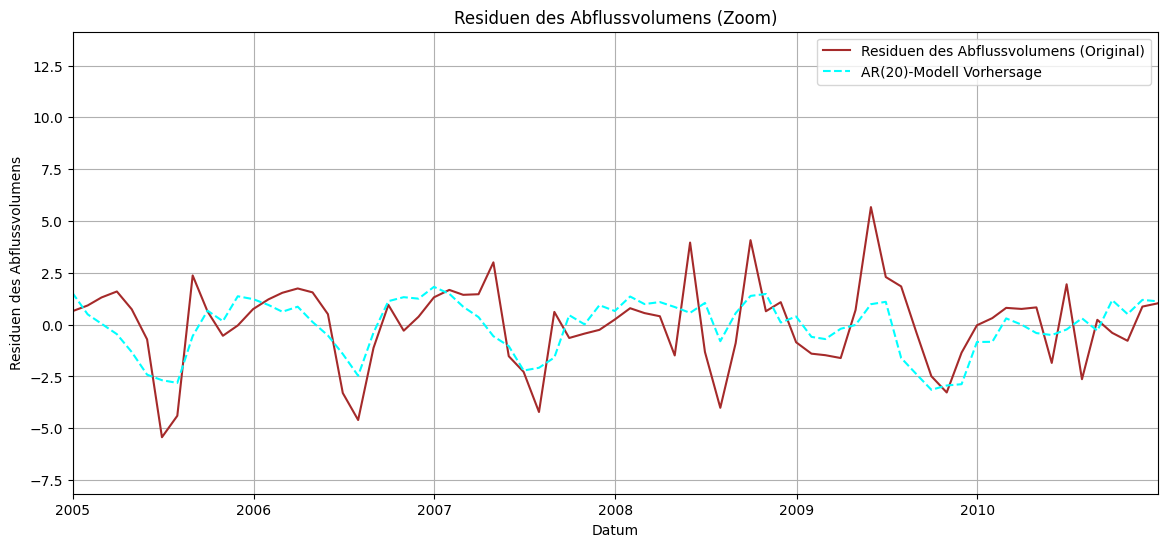

In [145]:
# AR(20) Modell für die Residuen des Abflussvolumens fitten
vol_resid_model = AutoReg(df_train['vol_resid'].dropna(), lags=20).fit()
vol_resid_pred = vol_resid_model.fittedvalues
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['vol_resid'], label='Residuen des Abflussvolumens (Original)', color='brown')
plt.plot(vol_resid_pred.index, vol_resid_pred, label='AR(20)-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Residuen des Abflussvolumens')
plt.title('Residuen des Abflussvolumens mit AR(20)-Modell')
plt.grid(True)
plt.legend()
plt.show()

# Zoom in die Residuen
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['vol_resid'], label='Residuen des Abflussvolumens (Original)', color='brown')
plt.plot(vol_resid_pred.index, vol_resid_pred, label='AR(20)-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Residuen des Abflussvolumens')
plt.title('Residuen des Abflussvolumens (Zoom)')
plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2010-12-31'))
plt.grid(True)
plt.legend()
plt.show()

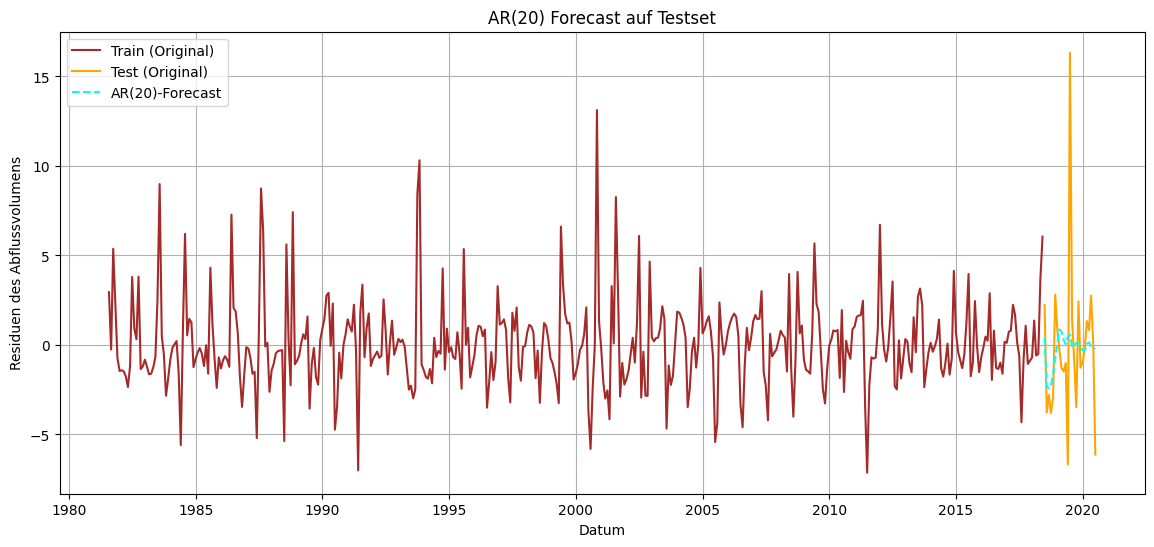

In [146]:
n_test = len(df_test)

vol_resid_forecast = vol_resid_model.predict(
    start=len(df_train),
    end=len(df_train) + n_test - 1
)

vol_resid_forecast.index = df_test.index

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['vol_resid'], 
         label='Train (Original)', color='brown')

# Test (Ground Truth)
plt.plot(df_test.index, df_test['vol_resid'], 
         label='Test (Original)', color='orange')

# Forecast
plt.plot(df_test.index, vol_resid_forecast, 
         label='AR(20)-Forecast', color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Residuen des Abflussvolumens')
plt.title('AR(20) Forecast auf Testset')
plt.grid(True)
plt.legend()
plt.show()

### Zusammenführung der Vorhersagen

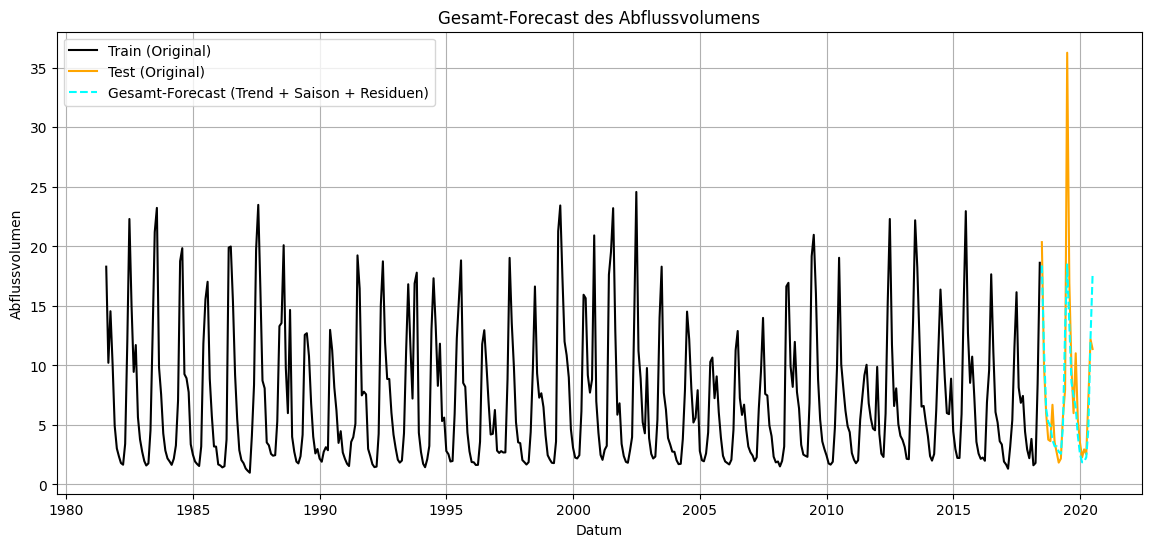

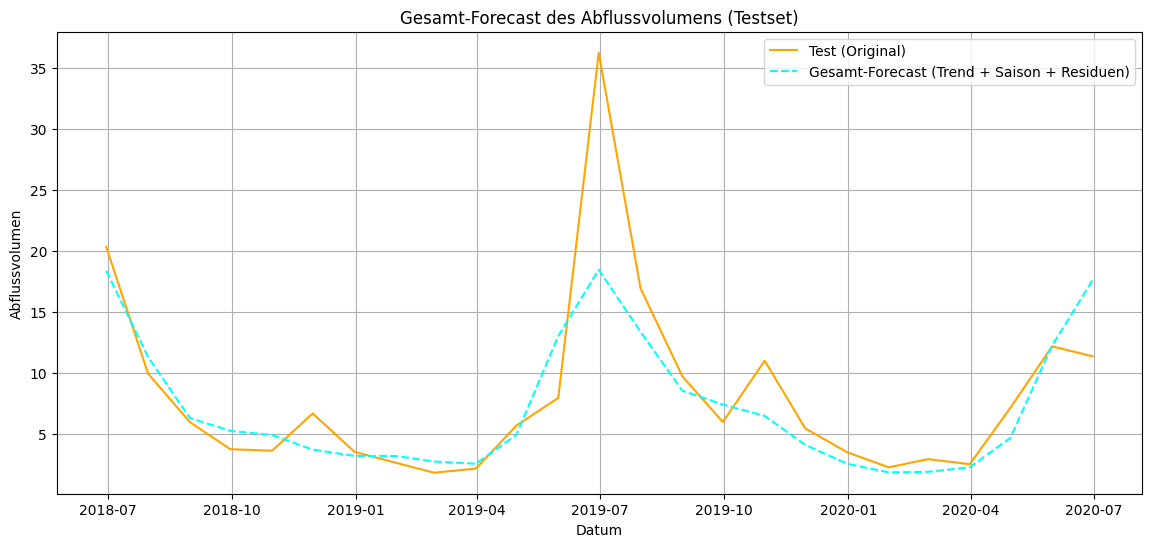

RMSE: 17.9517
MAE:  2.3503


In [147]:
vol_forecast_total = (
    vol_trend_forecast
    + season_vol_forecast
    + vol_resid_forecast
)

vol_forecast_total.name = 'vol_forecast'

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['vol_obs'],
         label='Train (Original)', color='black')

# Test
plt.plot(df_test.index, df_test['vol_obs'],
         label='Test (Original)', color='orange')

# Forecast
plt.plot(vol_forecast_total.index, vol_forecast_total,
         label='Gesamt-Forecast (Trend + Saison + Residuen)',
         color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Abflussvolumen')
plt.title('Gesamt-Forecast des Abflussvolumens')
plt.grid(True)
plt.legend()
plt.show()

# Zoom nur auf das Testset
plt.figure(figsize=(14, 6))
plt.plot(df_test.index, df_test['vol_obs'],
         label='Test (Original)', color='orange')
plt.plot(vol_forecast_total.index, vol_forecast_total,
         label='Gesamt-Forecast (Trend + Saison + Residuen)', 
            color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Abflussvolumen')
plt.title('Gesamt-Forecast des Abflussvolumens (Testset)')
plt.grid(True)
plt.legend()
plt.show()

rmse = mean_squared_error(df_test['vol_obs'], vol_forecast_total)
mae = mean_absolute_error(df_test['vol_obs'], vol_forecast_total)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

Wie erwartet sieht der Forecast des Abflussvolumens dem der Wasserstände sehr ähnlich. Es gibt die gleichen Probleme und Stärken wie bei den Wasserständen.

## Vorhersage der mittleren Temperatur
### Trend der mittleren Temperatur
Hier sehen wir, dass unser Trend über die Jahre hinweg ansteigt. Dies könnte auf den Klimawandel hindeuten, der zu einem allgemeinen Anstieg der Temperaturen führt. Wir wollen diesen Trend mithilfe einer linearen Regression modellieren.

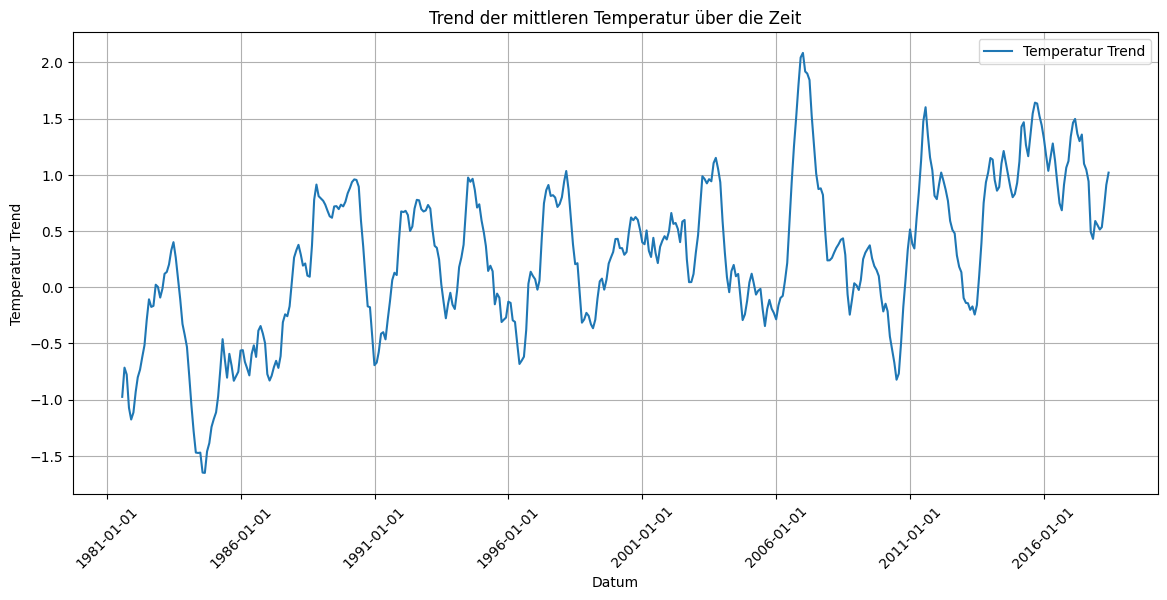

In [148]:
# Trend der Temperatur modellieren
# Anzeigen des Trends (Datum nur alle 5 Jahre)
xticks = pd.date_range(
    start=df_train.index.min().replace(month=1, day=1),
    end=df_train.index.max(),
    freq='5YS'   # 5-year start frequency
)

plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_trend'], label='Temperatur Trend')
plt.xlabel('Datum')
plt.ylabel('Temperatur Trend')
plt.title('Trend der mittleren Temperatur über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

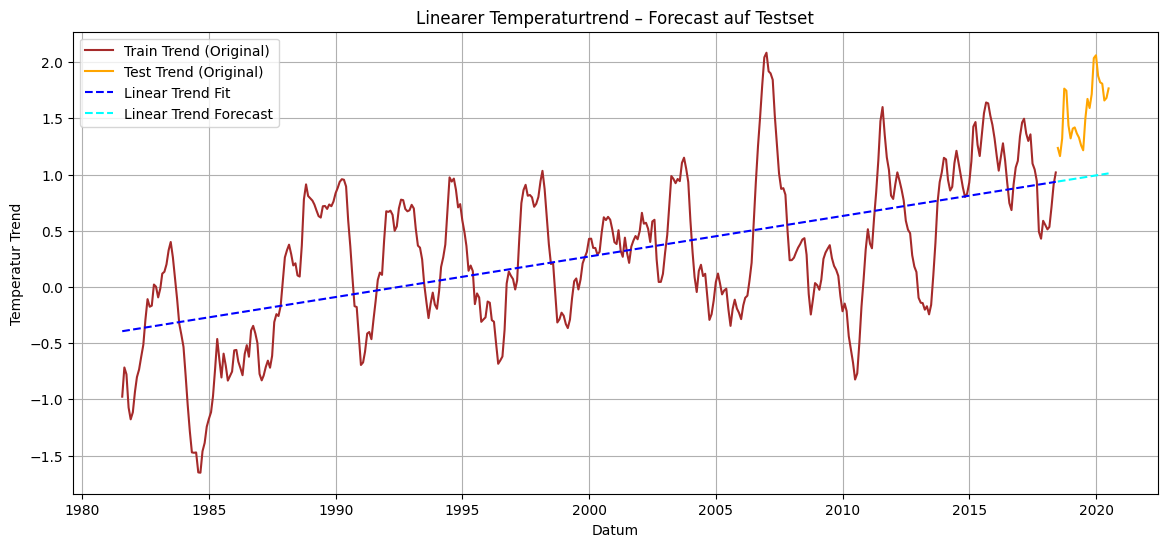

In [152]:
# Trend durch lineare Regression modellieren
from sklearn.linear_model import LinearRegression
t0 = df_train.index.min()

X_train = (df_train.index - t0).days.values.reshape(-1, 1)
X_test  = (df_test.index  - t0).days.values.reshape(-1, 1)

y_train = df_train['temp_trend'].values

temp_trend_model = LinearRegression()
temp_trend_model.fit(X_train, y_train)

temp_trend_pred = temp_trend_model.predict(X_train)

temp_trend_forecast = temp_trend_model.predict(X_test)

temp_trend_forecast = pd.Series(
    temp_trend_forecast,
    index=df_test.index,
    name='temp_trend_forecast'
)

plt.figure(figsize=(14, 6))

plt.plot(df_train.index, df_train['temp_trend'],
         label='Train Trend (Original)', color='brown')

plt.plot(df_test.index, df_test['temp_trend'],
         label='Test Trend (Original)', color='orange')

plt.plot(df_train.index, temp_trend_pred,
         label='Linear Trend Fit', color='blue', linestyle='--')

plt.plot(temp_trend_forecast.index, temp_trend_forecast,
         label='Linear Trend Forecast', color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Temperatur Trend')
plt.title('Linearer Temperaturtrend – Forecast auf Testset')
plt.grid(True)
plt.legend()
plt.show()


Es ist zu erkennen, dass der Trend der mittleren Temperatur über die Jahre hinweg ansteigt. Auf dem Testset passt die Regression nicht exakt, aber wenn man den allgemeinen Trend betrachtet, ist die Vorhersage akzeptabel.

### Saisonalität der mittleren Temperatur
Hier nehmen wir erneut die Saisonalität aus dem Trainingsset und nutzen diese für die Vorhersage im Testset.

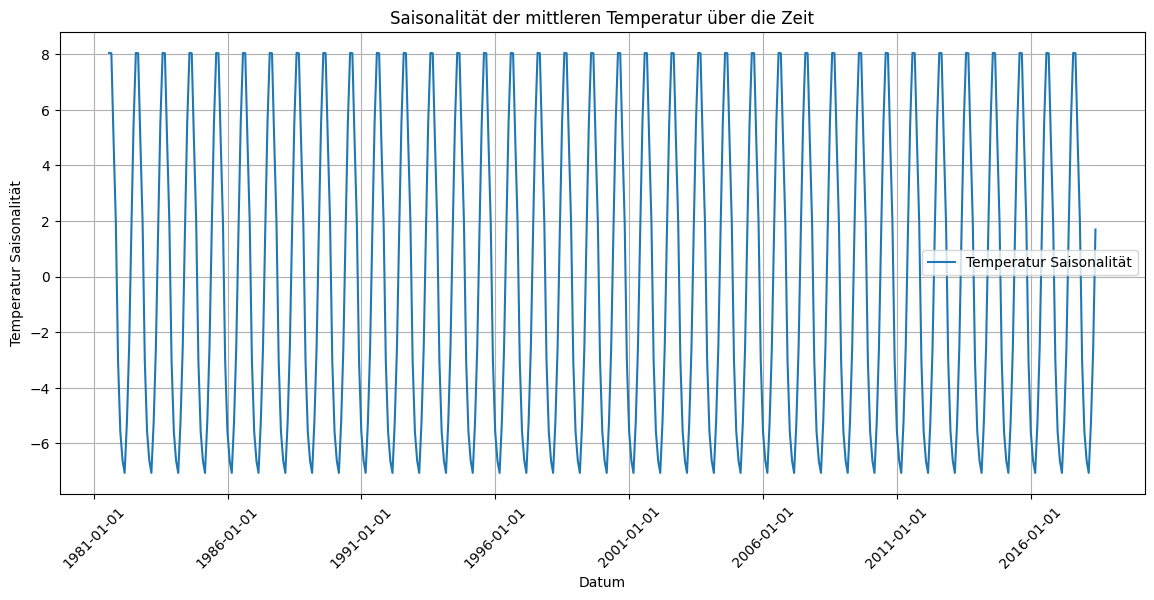

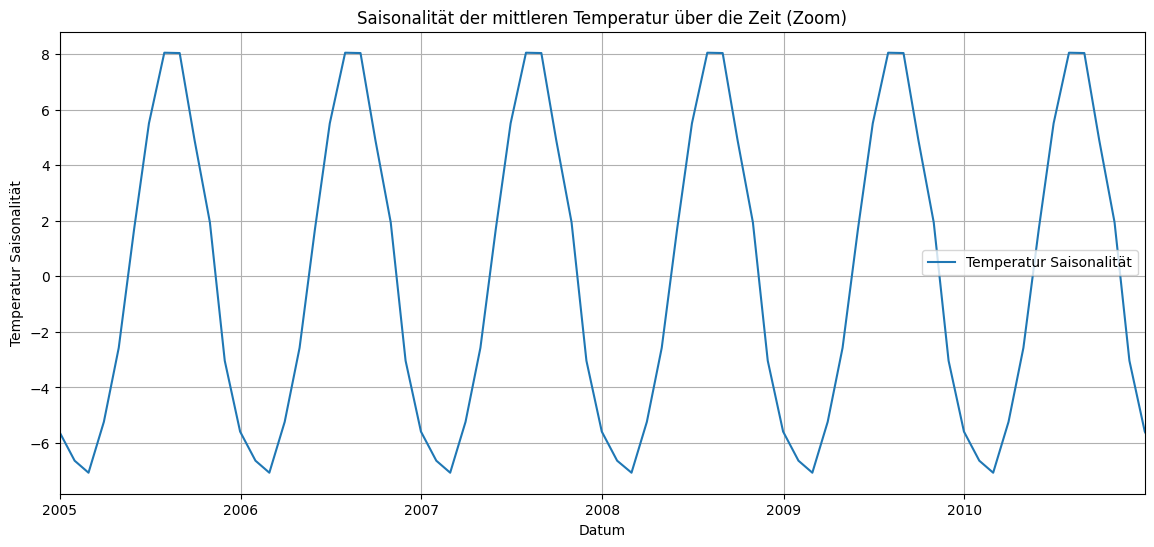

In [153]:
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_seasonal'], label='Temperatur Saisonalität')
plt.xlabel('Datum')
plt.ylabel('Temperatur Saisonalität')
plt.title('Saisonalität der mittleren Temperatur über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

# Zoom in die Saisonalität
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_seasonal'], label='Temperatur Saisonalität')
plt.xlabel('Datum')
plt.ylabel('Temperatur Saisonalität')
plt.title('Saisonalität der mittleren Temperatur über die Zeit (Zoom)')
plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2010-12-31'))
plt.grid(True)
plt.legend()
plt.show()

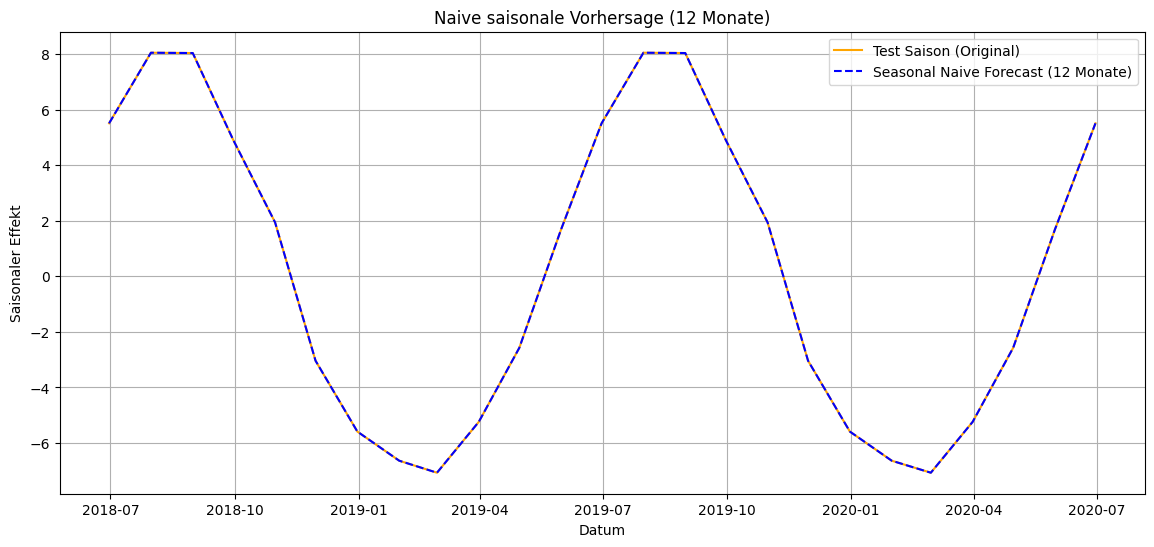

In [154]:
season_length = 12  # Monate in einer Saison

last_season = df_train['temp_seasonal'].iloc[-season_length:]

n_test = len(df_test)

season_temp_forecast = np.tile(
    last_season.values,
    int(np.ceil(n_test / season_length))
)[:n_test]

season_temp_forecast = pd.Series(
    season_temp_forecast,
    index=df_test.index,
    name='season_naive_forecast'
)

plt.figure(figsize=(14, 6))

plt.plot(df_test.index, df_test['temp_seasonal'], 
         label='Test Saison (Original)', color='orange')

plt.plot(season_temp_forecast.index, season_temp_forecast, 
         label='Seasonal Naive Forecast (12 Monate)', 
         color='blue', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Saisonaler Effekt')
plt.title('Naive saisonale Vorhersage (12 Monate)')
plt.grid(True)
plt.legend()
plt.show()

Hier passt die naive Saisonalitätsvorhersage der mittleren Temperatur wie auch bei den anderen Variablen exakt auf die Originaldaten im Testset.

### Residuen der mittleren Temperatur
Hier könnten wir ein AR(37) Modell in Betracht ziehen, da die PACF sehr lange negativ ausserhalb des Signifikanzniveaus bleibt. Vielleicht reicht auch ein AR(12) Modell. Wir werden beides versuchen und das bessere Modell behalten.

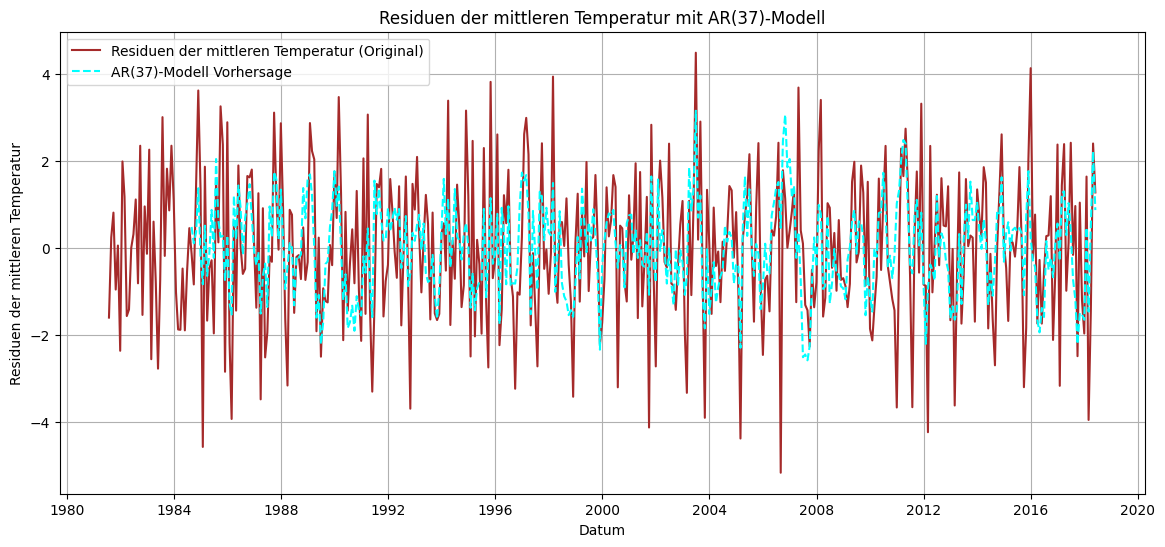

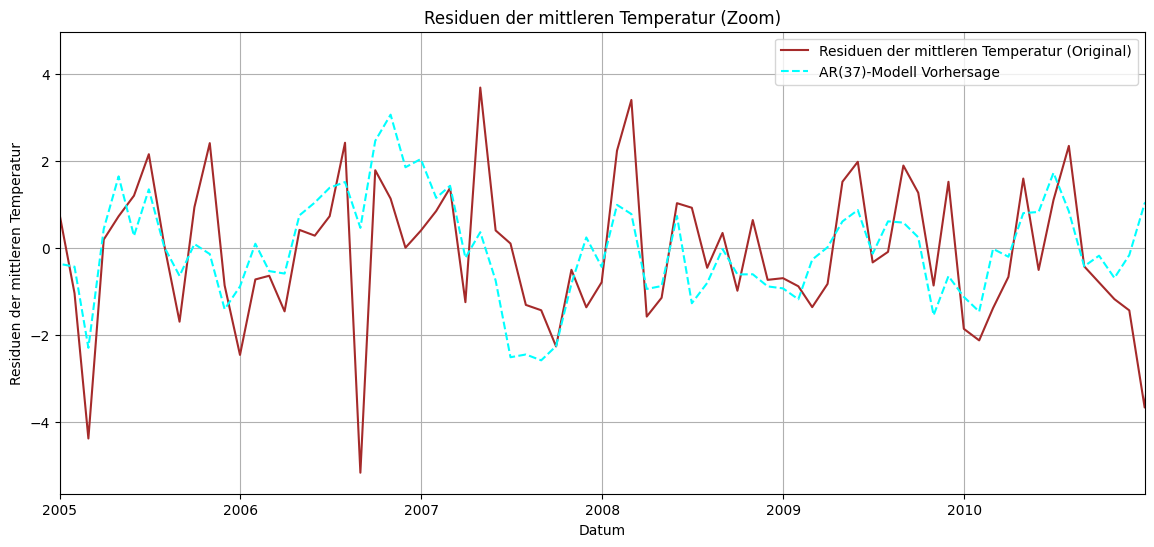

In [157]:
# AR(37) Modell für die Residuen der mittleren Temperatur fitten
temp_resid_model = AutoReg(df_train['temp_resid'].dropna(), lags=37).fit()
temp_resid_pred = temp_resid_model.fittedvalues
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_resid'], label='Residuen der mittleren Temperatur (Original)', color='brown')
plt.plot(temp_resid_pred.index, temp_resid_pred, label='AR(37)-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Residuen der mittleren Temperatur')
plt.title('Residuen der mittleren Temperatur mit AR(37)-Modell')
plt.grid(True)
plt.legend()
plt.show()

# Zoom in die Residuen
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_resid'], label='Residuen der mittleren Temperatur (Original)', color='brown')
plt.plot(temp_resid_pred.index, temp_resid_pred, label='AR(37)-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Residuen der mittleren Temperatur')
plt.title('Residuen der mittleren Temperatur (Zoom)')
plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2010-12-31'))
plt.grid(True)
plt.legend()
plt.show()

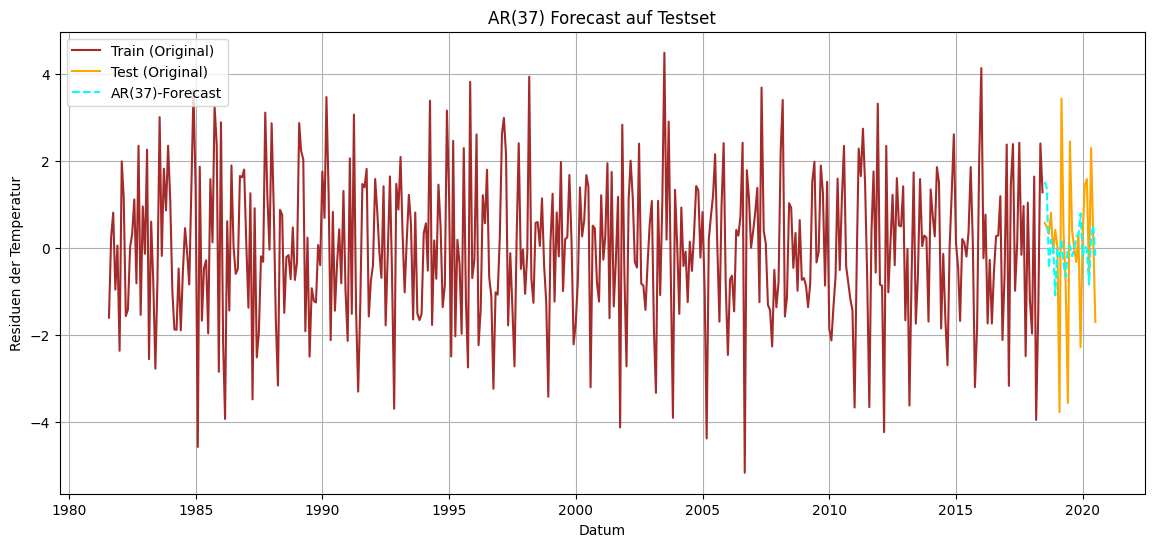

In [159]:
n_test = len(df_test)

temp_resid_forecast = temp_resid_model.predict(
    start=len(df_train),
    end=len(df_train) + n_test - 1
)

temp_resid_forecast.index = df_test.index

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['temp_resid'], 
         label='Train (Original)', color='brown')

# Test (Ground Truth)
plt.plot(df_test.index, df_test['temp_resid'], 
         label='Test (Original)', color='orange')

# Forecast
plt.plot(df_test.index, temp_resid_forecast, 
         label='AR(37)-Forecast', color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Residuen der Temperatur')
plt.title('AR(37) Forecast auf Testset')
plt.grid(True)
plt.legend()
plt.show()

Das Modell erfasst im Grundsatz die Änderungen nicht schlecht, hat aber starke Probleme bei den grösseren Ausschlägen. Wir behalten aber das AR(37) Modell, da es etwas besser ist als das AR(12) Modell.

### Zusammenführung der Vorhersagen

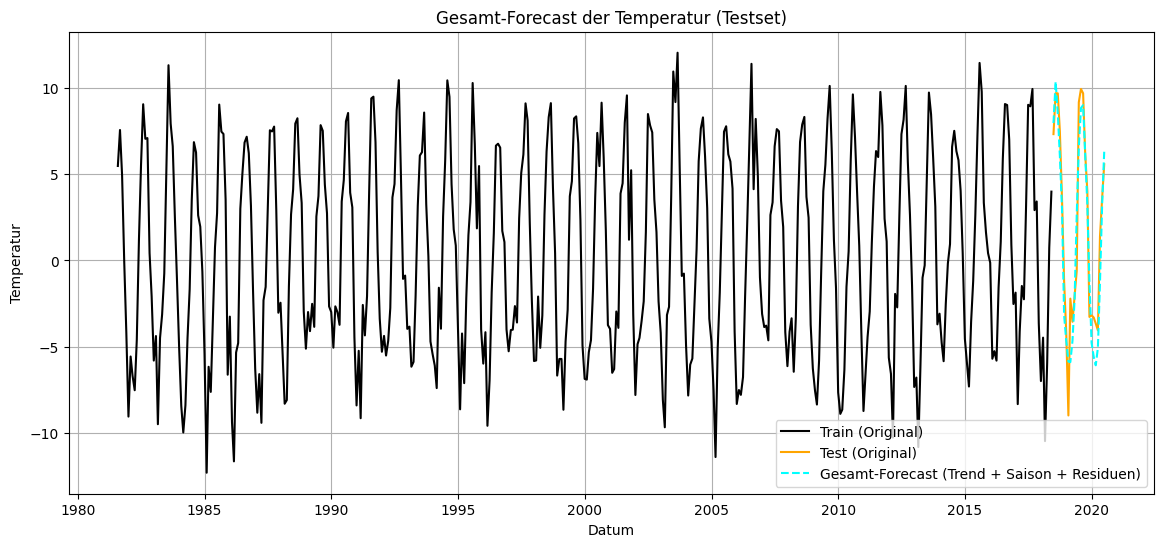

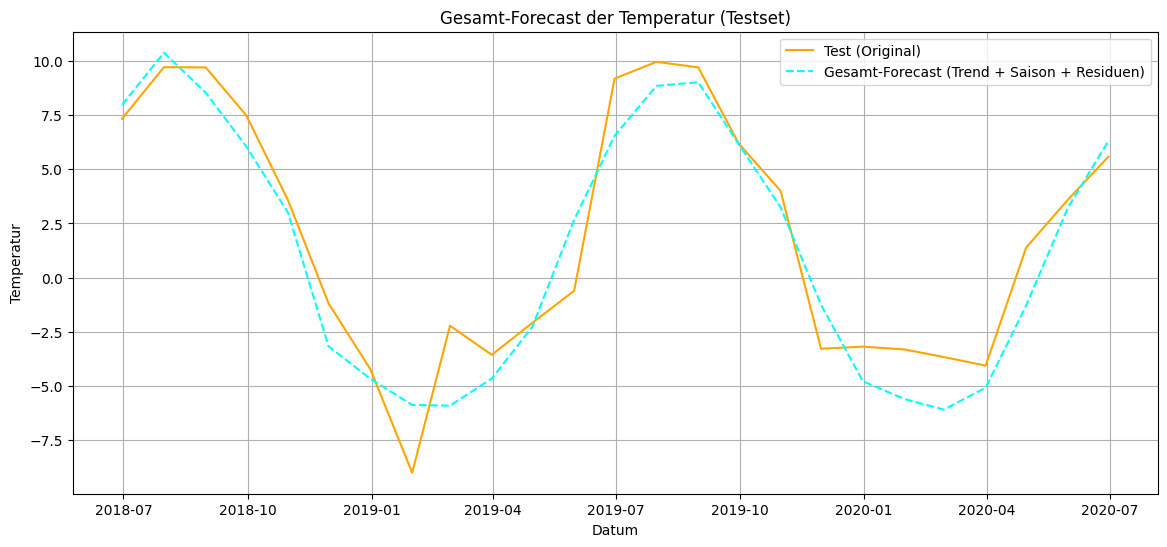

RMSE: 3.1951
MAE:  1.4647


In [160]:
temp_forecast_total = (
    temp_trend_forecast
    + season_temp_forecast
    + temp_resid_forecast
)

temp_forecast_total.name = 'temp_forecast'

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['temp_obs'],
         label='Train (Original)', color='black')

# Test
plt.plot(df_test.index, df_test['temp_obs'],
         label='Test (Original)', color='orange')

# Forecast
plt.plot(temp_forecast_total.index, temp_forecast_total,
         label='Gesamt-Forecast (Trend + Saison + Residuen)',
         color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Temperatur')
plt.title('Gesamt-Forecast der Temperatur (Testset)')
plt.grid(True)
plt.legend()
plt.show()

# Zoom nur auf das Testset
plt.figure(figsize=(14, 6))
plt.plot(df_test.index, df_test['temp_obs'],
         label='Test (Original)', color='orange')
plt.plot(temp_forecast_total.index, temp_forecast_total,
         label='Gesamt-Forecast (Trend + Saison + Residuen)', 
            color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Temperatur')
plt.title('Gesamt-Forecast der Temperatur (Testset)')
plt.grid(True)
plt.legend()
plt.show()

rmse = mean_squared_error(df_test['temp_obs'], temp_forecast_total)
mae = mean_absolute_error(df_test['temp_obs'], temp_forecast_total)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

Bei den Temperaturen sieht der Forecast insgesamt gut aus. Die Saisonalität und der Trend werden gut erfasst, nur die Residuen sind etwas schwierig zu modellieren. Dennoch ist die Gesamtvorhersage akzeptabel.

## Vorhersage der Niederschlagsmenge
### Trend der Niederschlagsmenge
Beim Trend der Niederschlagsmenge versuchen wir ebenfalls ein ARIMA Modell zu nutzen.

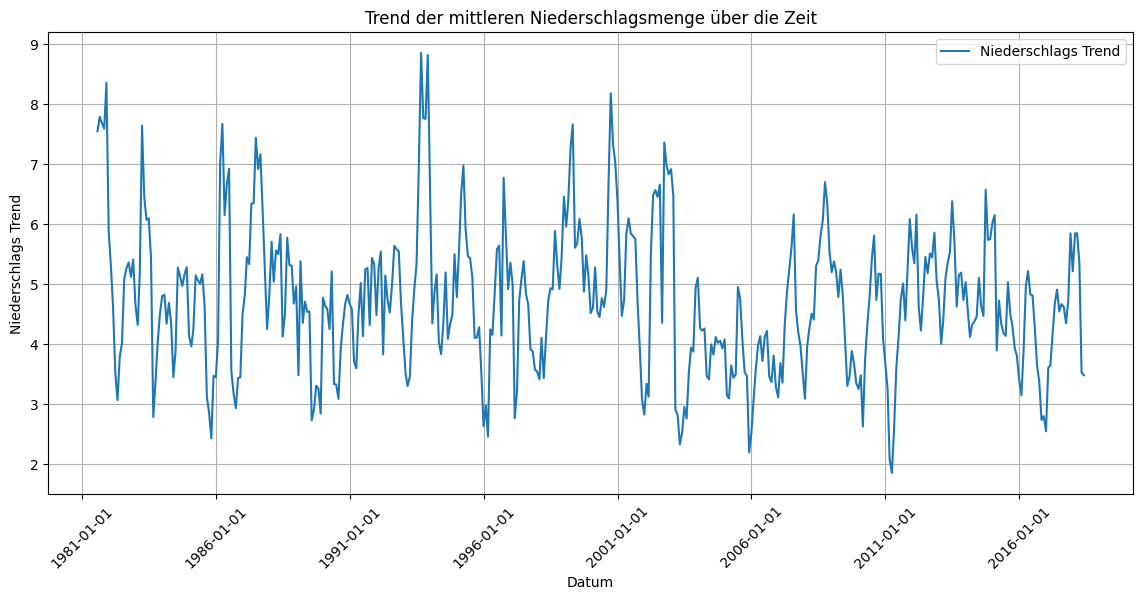

In [161]:
# Trend des Niederschlags modellieren
# Anzeigen des Trends (Datum nur alle 5 Jahre)
xticks = pd.date_range(
    start=df_train.index.min().replace(month=1, day=1),
    end=df_train.index.max(),
    freq='5YS'   # 5-year start frequency
)

plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['rain_trend'], label='Niederschlags Trend')
plt.xlabel('Datum')
plt.ylabel('Niederschlags Trend')
plt.title('Trend der mittleren Niederschlagsmenge über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

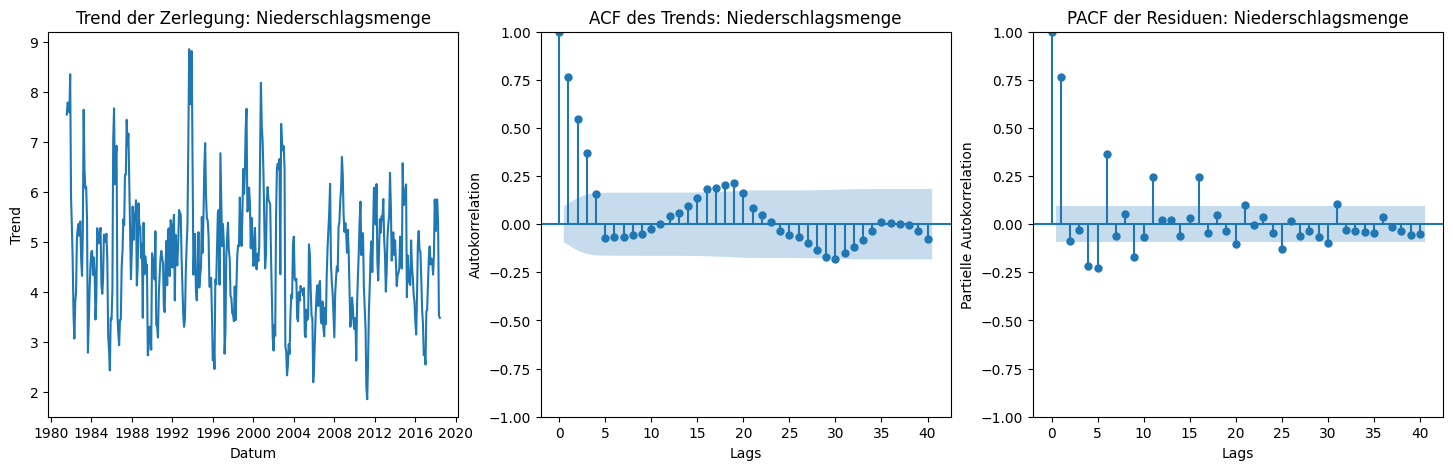

In [162]:
acf_pacf_plots_decomposed(df_train['rain_trend'].dropna(), 'Niederschlagsmenge')

Wir sehen ein abfallend schwankendes Verhalten in der ACF, während die PACF stärker abfällt aber auch schwankt. Hier versuchen wir nun ein ARIMA Modell zu erstellen, welches sich automatisch die besten Parameter sucht.

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  443
Model:               SARIMAX(4, 0, 2)   Log Likelihood                -441.139
Date:                Mo., 15 Dez 2025   AIC                            898.278
Time:                        13:42:11   BIC                            931.027
Sample:                    07-31-1981   HQIC                           911.194
                         - 05-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.8494      0.193      9.590      0.000       1.471       2.227
ar.L1          1.3281      0.044     30.393      0.000       1.242       1.414
ar.L2         -1.1612      0.069    -16.926      0.0

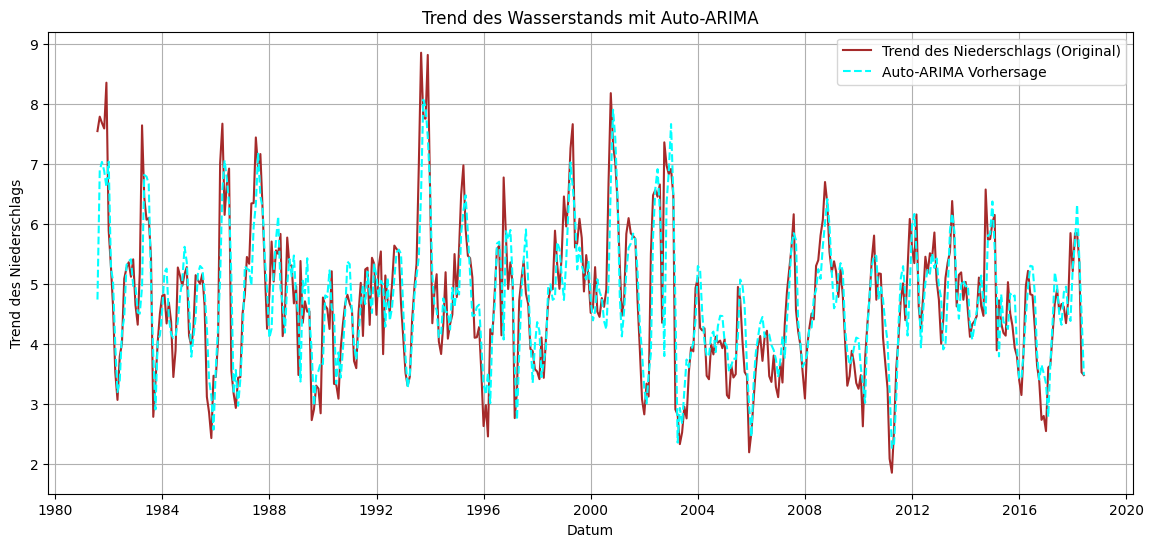

In [ ]:
from pmdarima import auto_arima

rain_trend = df_train['rain_trend'].dropna()

auto_model = auto_arima(
    rain_trend,
    start_p=0,
    max_p=5,
    start_q=0,
    max_q=5,
    d=None,              # automatisch differenzieren
    seasonal=False,      # Trend → keine Saison
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True
)

print(auto_model.summary())

Aus dem Auto SARIMAX Modell erhalten wir die Parameter p=4, d=0, q=2 für das ARIMA Modell. Wir nutzen diese nun um den Trend der Niederschlagsmenge zu modellieren.

c:\Users\Adrian Meier\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Adrian Meier\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Adrian Meier\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


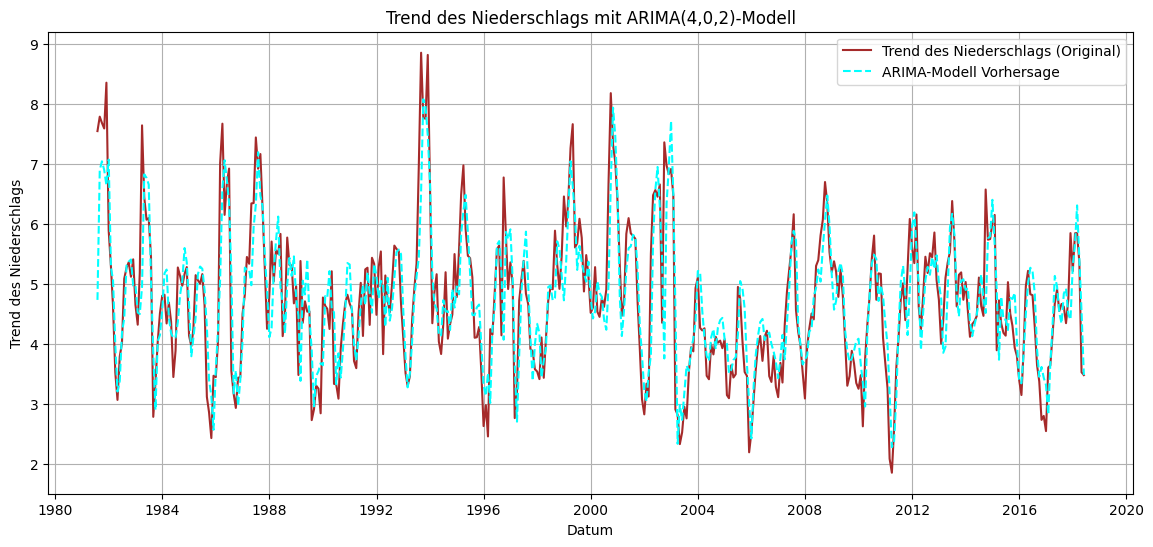

In [172]:
from statsmodels.tsa.arima.model import ARIMA
rain_trend_model = ARIMA(df_train['rain_trend'], order=(4,0,2))
rain_trend_model = rain_trend_model.fit()
rain_trend_pred = rain_trend_model.fittedvalues
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['rain_trend'], label='Trend des Niederschlags (Original)', color='brown')
plt.plot(rain_trend_pred.index, rain_trend_pred, label='ARIMA-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Trend des Niederschlags')
plt.title('Trend des Niederschlags mit ARIMA(4,0,2)-Modell')
plt.grid(True)
plt.legend()
plt.show()

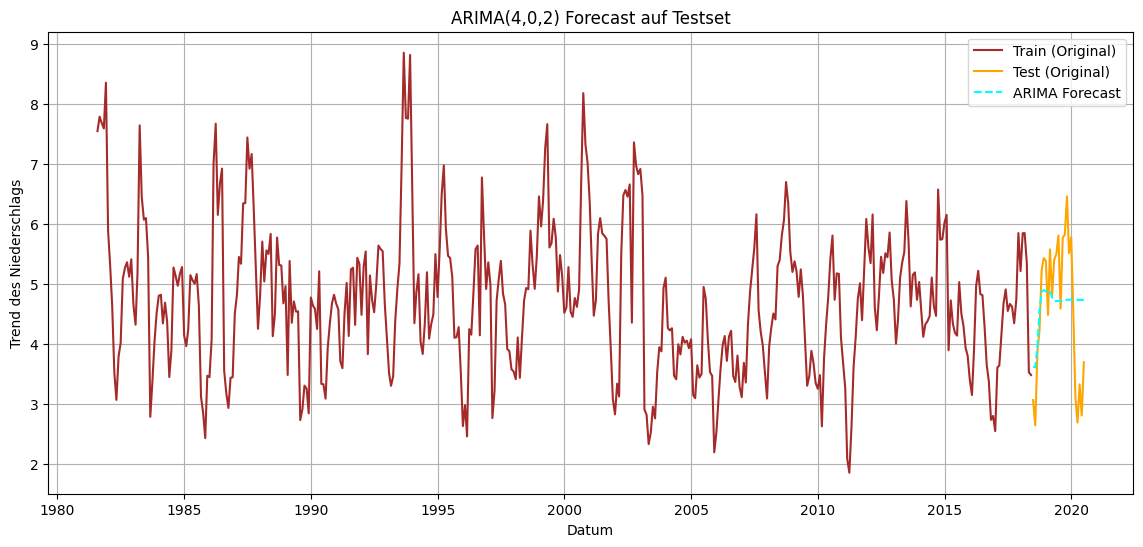

In [173]:
n_test = len(df_test)

rain_trend_forecast = rain_trend_model.predict(
    start=len(df_train),
    end=len(df_train) + n_test - 1
)

rain_trend_forecast.index = df_test.index

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['rain_trend'], 
         label='Train (Original)', color='brown')

# Test (Ground Truth)
plt.plot(df_test.index, df_test['rain_trend'], 
         label='Test (Original)', color='orange')

# Forecast
plt.plot(df_test.index, rain_trend_forecast, 
         label='ARIMA Forecast', color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Trend des Niederschlags')
plt.title('ARIMA(4,0,2) Forecast auf Testset')
plt.grid(True)
plt.legend()
plt.show()

Das Modell fittet die ersten Punkte im Testset gut, danach verliert es aber den Anschluss an die Originaldaten. Dies liegt daran, dass nach einigen Lags die Werte nicht mehr berücksichtigt werden. Dadurch ist das Modell nicht in der Lage den Trend langfristig zu verfolgen.

### Saisonalität der Niederschlagsmenge
Hier gehen wir wieder gleich vor wie bei den anderen Variablen und übernehmen die Saisonalität aus dem Trainingsset. Der unterschied hier ist, dass die Saisonalität in einem 5 Monats Zyklus auftritt, anstatt in einem 12 Monats Zyklus.

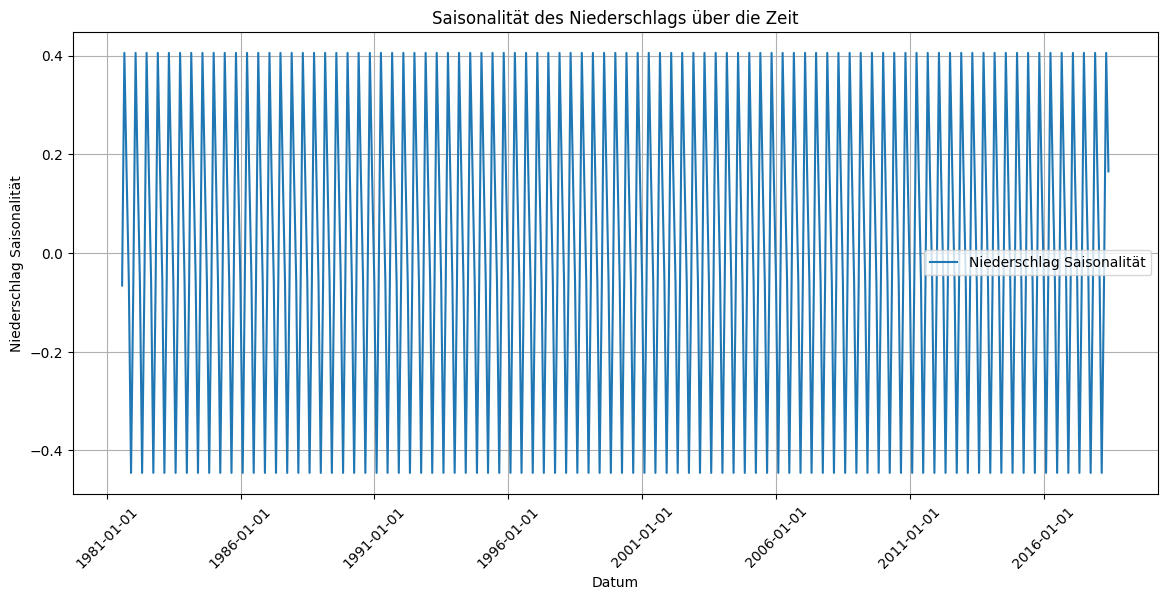

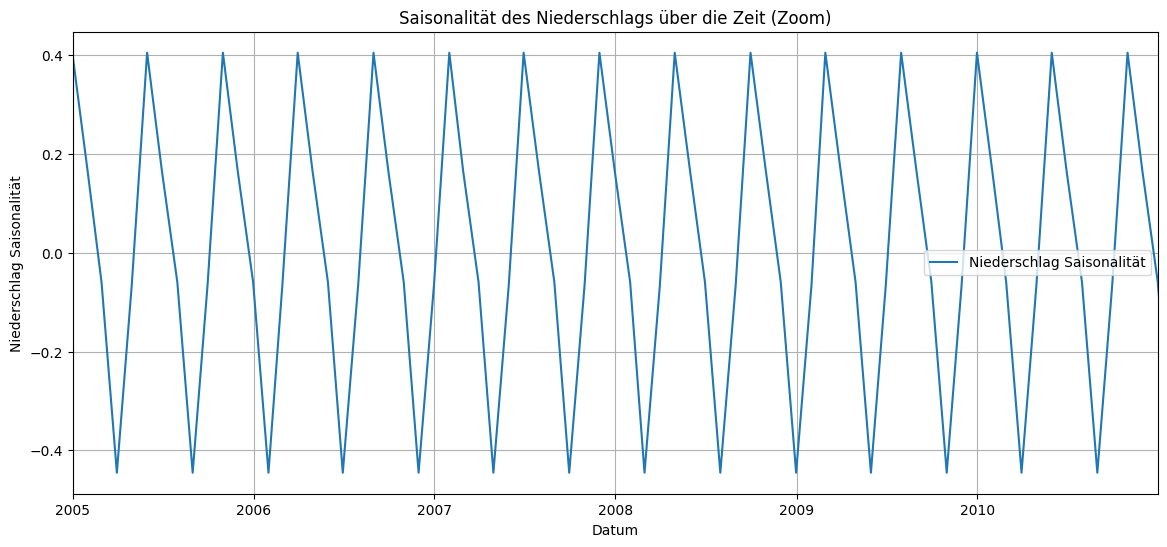

In [174]:
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['rain_seasonal'], label='Niederschlag Saisonalität')
plt.xlabel('Datum')
plt.ylabel('Niederschlag Saisonalität')
plt.title('Saisonalität des Niederschlags über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

# Zoom in die Saisonalität
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['rain_seasonal'], label='Niederschlag Saisonalität')
plt.xlabel('Datum')
plt.ylabel('Niederschlag Saisonalität')
plt.title('Saisonalität des Niederschlags über die Zeit (Zoom)')
plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2010-12-31'))
plt.grid(True)
plt.legend()
plt.show()

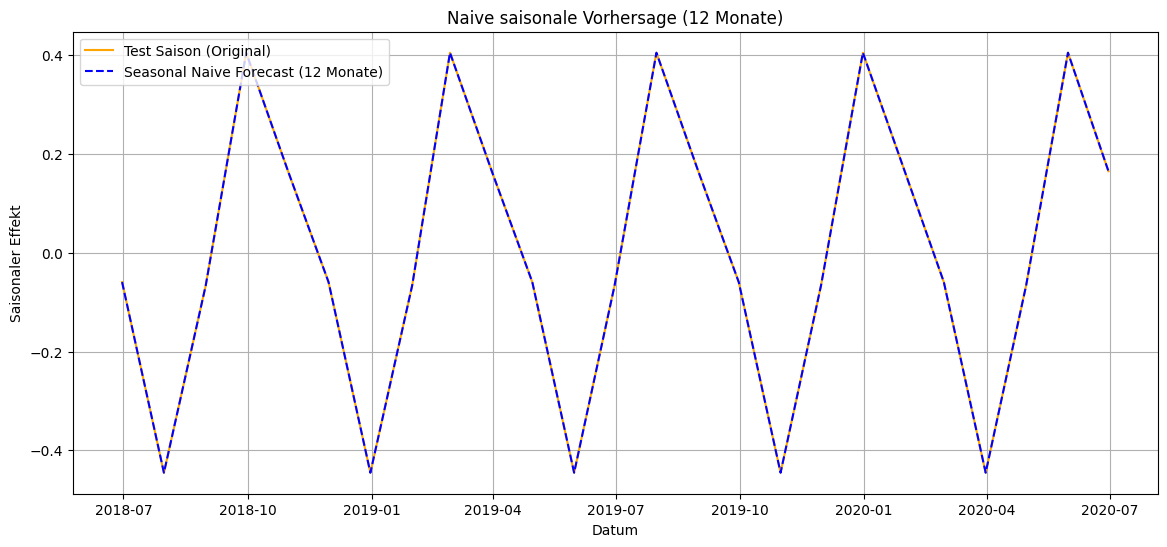

In [ ]:
season_length = 5  # Monate in einer Saison

last_season = df_train['rain_seasonal'].iloc[-season_length:]

n_test = len(df_test)

season_rain_forecast = np.tile(
    last_season.values,
    int(np.ceil(n_test / season_length))
)[:n_test]

season_rain_forecast = pd.Series(
    season_rain_forecast,
    index=df_test.index,
    name='season_naive_forecast'
)

plt.figure(figsize=(14, 6))

plt.plot(df_test.index, df_test['rain_seasonal'], 
         label='Test Saison (Original)', color='orange')

plt.plot(season_rain_forecast.index, season_rain_forecast, 
         label='Seasonal Naive Forecast (5 Monate)', 
         color='blue', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Saisonaler Effekt')
plt.title('Naive saisonale Vorhersage (5 Monate)')
plt.grid(True)
plt.legend()
plt.show()

Mit einem 5 Monats Zyklus passt die Saisonalität der Niederschlagsmenge sehr gut auf die Originaldaten im Testset.

### Residuen der Niederschlagsmenge
Hier könnten wir ein MA(3) oder MA(20) Modell in Betracht ziehen. Wir probieren hier beides aus und schauen welches besser funktioniert.

c:\Users\Adrian Meier\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


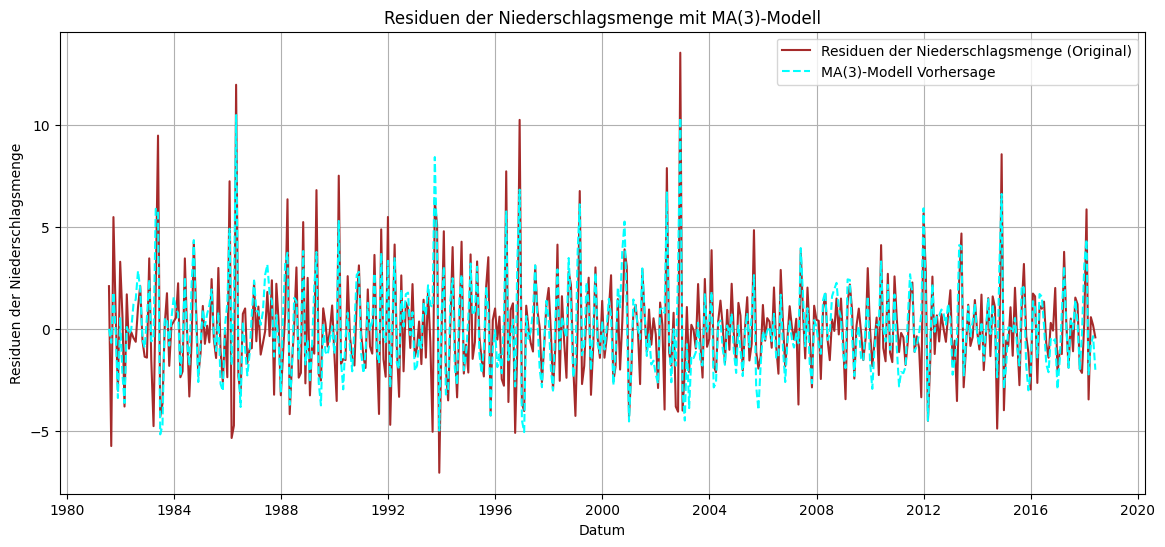

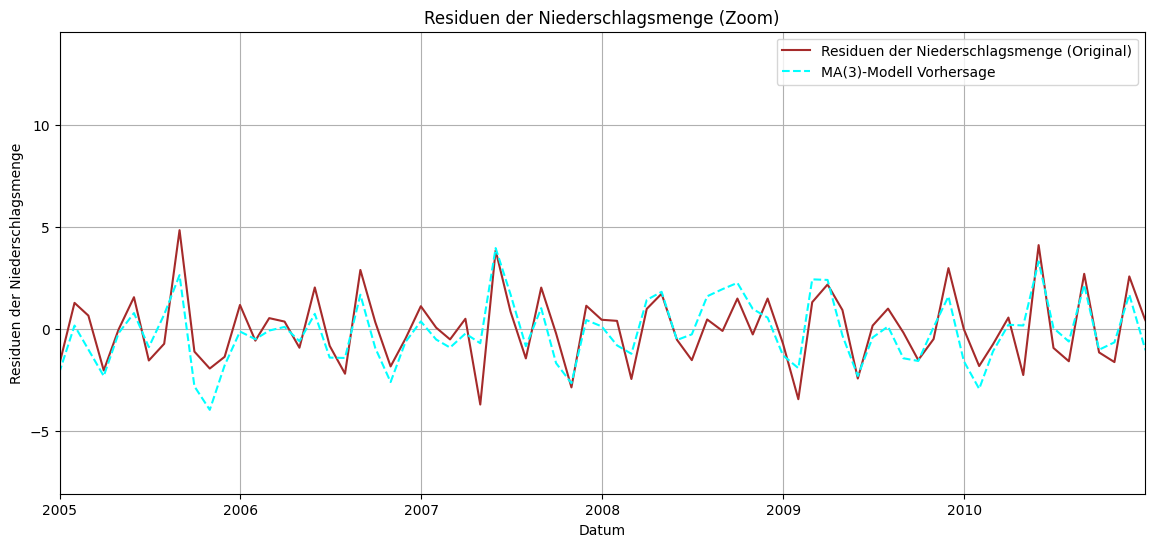

In [177]:
# MA(3) Modell für die Residuen der Niederschlagsmenge fitten
from statsmodels.tsa.arima.model import ARIMA
rain_resid_model = ARIMA(df_train['rain_resid'].dropna(), order=(0,0,3)).fit()
rain_resid_pred = rain_resid_model.fittedvalues
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['rain_resid'], label='Residuen der Niederschlagsmenge (Original)', color='brown')
plt.plot(rain_resid_pred.index, rain_resid_pred, label='MA(3)-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Residuen der Niederschlagsmenge')
plt.title('Residuen der Niederschlagsmenge mit MA(3)-Modell')
plt.grid(True)
plt.legend()
plt.show()

# Zoom in die Residuen
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['rain_resid'], label='Residuen der Niederschlagsmenge (Original)', color='brown')
plt.plot(rain_resid_pred.index, rain_resid_pred, label='MA(3)-Modell Vorhersage', 
         color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Residuen der Niederschlagsmenge')
plt.title('Residuen der Niederschlagsmenge (Zoom)')
plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2010-12-31'))
plt.grid(True)
plt.legend()
plt.show()

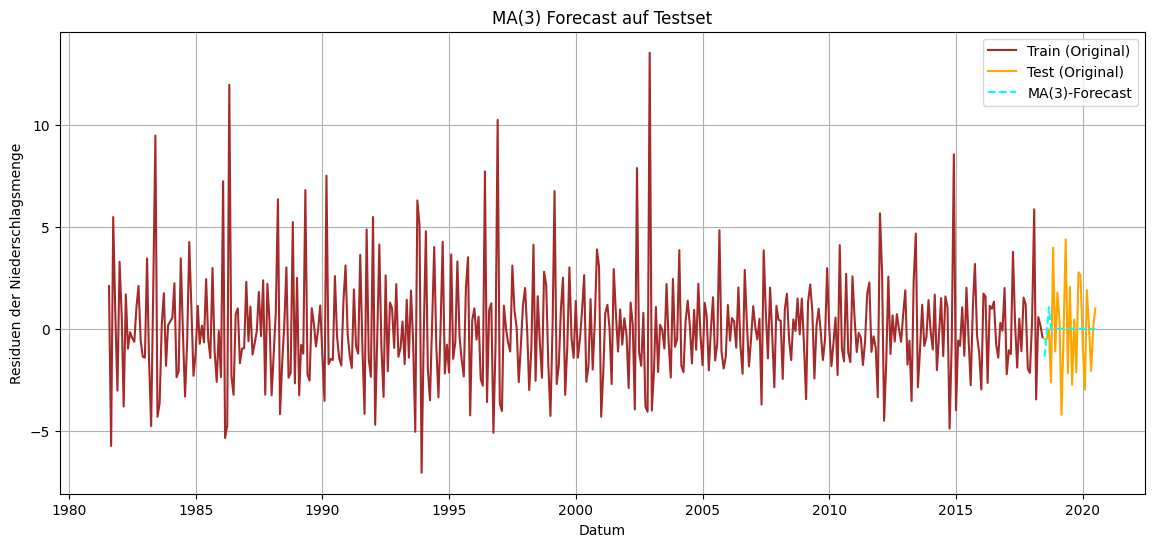

In [178]:
n_test = len(df_test)

rain_resid_forecast = rain_resid_model.predict(
    start=len(df_train),
    end=len(df_train) + n_test - 1
)

rain_resid_forecast.index = df_test.index

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['rain_resid'], 
         label='Train (Original)', color='brown')

# Test (Ground Truth)
plt.plot(df_test.index, df_test['rain_resid'], 
         label='Test (Original)', color='orange')

# Forecast
plt.plot(df_test.index, rain_resid_forecast, 
         label='MA(3)-Forecast', color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Residuen der Niederschlagsmenge')
plt.title('MA(3) Forecast auf Testset')
plt.grid(True)
plt.legend()
plt.show()

Die Residuen des MA(3) sehen gut aus und modellieren die Residuen im Trainingsset gut. Wir behalten dieses Modell. Im Testset wird natürlich wieder der Anschluss verloren, da nur die letzten 3 Lags berücksichtigt werden.

### Zusammenführung der Vorhersagen

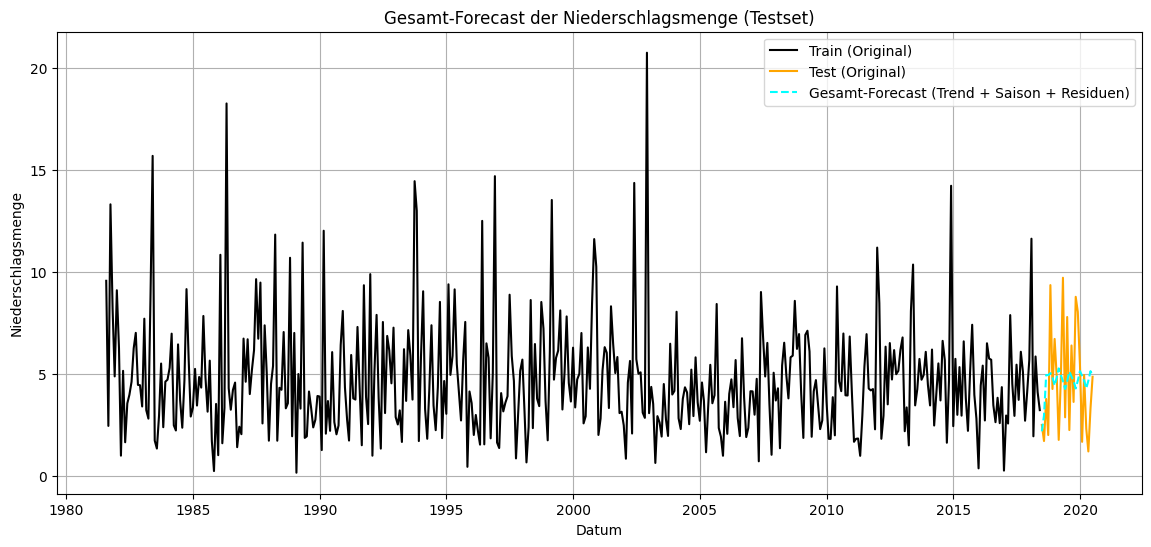

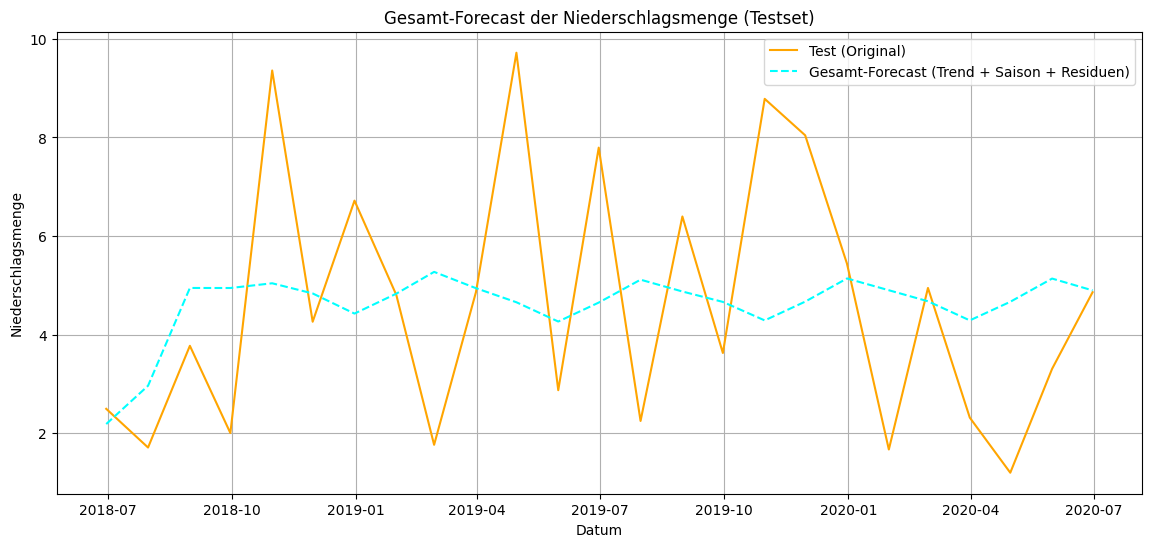

RMSE: 6.3457
MAE:  2.0184


In [179]:
rain_forecast_total = (
    rain_trend_forecast
    + season_rain_forecast
    + rain_resid_forecast
)

rain_forecast_total.name = 'rain_forecast'

plt.figure(figsize=(14, 6))

# Train
plt.plot(df_train.index, df_train['rain_obs'],
         label='Train (Original)', color='black')

# Test
plt.plot(df_test.index, df_test['rain_obs'],
         label='Test (Original)', color='orange')

# Forecast
plt.plot(rain_forecast_total.index, rain_forecast_total,
         label='Gesamt-Forecast (Trend + Saison + Residuen)',
         color='cyan', linestyle='--')

plt.xlabel('Datum')
plt.ylabel('Niederschlagsmenge')
plt.title('Gesamt-Forecast der Niederschlagsmenge (Testset)')
plt.grid(True)
plt.legend()
plt.show()

# Zoom nur auf das Testset
plt.figure(figsize=(14, 6))
plt.plot(df_test.index, df_test['rain_obs'],
         label='Test (Original)', color='orange')
plt.plot(rain_forecast_total.index, rain_forecast_total,
         label='Gesamt-Forecast (Trend + Saison + Residuen)', 
            color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Niederschlagsmenge')
plt.title('Gesamt-Forecast der Niederschlagsmenge (Testset)')
plt.grid(True)
plt.legend()
plt.show()

rmse = mean_squared_error(df_test['rain_obs'], rain_forecast_total)
mae = mean_absolute_error(df_test['rain_obs'], rain_forecast_total)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

Beim Niederschlag macht die Saison einen weniger grossen Teil aus, als bei den anderen Variablen. Da dies normalerweise am besten nachgestellt werden konnte, ist hier der Forecast nicht ganz so gut wie bei den anderen Variablen. Es zeigt sich ein ähnliches Problem wie bei den täglichen Daten. Die Regendaten konnten zwar besser dekomponiert werden, aber die Modellierung ist immer noch schwierig, was zu weniger genauen Vorhersagen führt.

# Ausblick bei den monatlichen Daten
Es hat sich gezeigt, dass die Dekomposition auf den monatlich aggregierten Daten besser funktioniert hat als bei den täglichen Daten. Besonders bei den Regendaten konnte eine klarere Saisonalität erkannt werden und die Daten sind stabiler. Allerdings können auch hier die Regendaten nicht sehr gut modelliert werden, was zu weniger genauen Vorhersagen führt. Man könnte nun ähnlich wie bei den täglichen Daten versuchen, ein Modell zu erstellen, welches den Wasserstand direkt aus den anderen Variablen vorhersagt. Da wir aber keinen klaren und deutlichen Fortschritt in der Modellierung der Regendaten sehen konnten, ist es fraglich, ob dies zu besseren Ergebnissen führen würde. Dazu kommt, dass wir nur noch monatliche Daten zur Verfügung haben und dadurch auch nur monatliche Vorhersagen machen könnten. Dies mach für unsere Anwendung in unseren Augen wenig Sinn. Deshalb wird dieser Ansatz hier nicht weiter verfolgt. Dennoch konnten wir noch einige interessante Erkenntnisse gewinnen, die in zukünftigen Arbeiten nützlich sein könnten.